# 05 — v0 Analysis Prototype

Produces every candidate figure for the INFO801 Assessment 2 report, run across
all 13 held-out hero games. Outputs are saved to `results/figures/`.


In [1]:
# Setup
import sys, re, json, os
from pathlib import Path

sys.path.insert(0, "..")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)

FIG_DIR = Path("../results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Saving figures to", FIG_DIR.resolve())

EXCLUDE_HERO_GAMES = [13, 171, 181, 188, 320, 822, 1294, 1406, 2223, 2243, 2397, 2425, 50381]
HERO_NAMES = {
    13: "Catan", 171: "Chess", 181: "Risk", 188: "Go", 320: "Scrabble",
    822: "Carcassonne", 1294: "Clue", 1406: "Monopoly", 2223: "UNO",
    2243: "Yahtzee", 2397: "Backgammon", 2425: "Battleship",
    50381: "Cards Against Humanity",
}

df = pd.read_csv("../data/games_processed.csv")
hero_mask = df["BGGId"].isin(EXCLUDE_HERO_GAMES)
hero_df = df[hero_mask].copy().reset_index(drop=True)
train_df = df[~hero_mask].copy()
print(f"Loaded {len(df):,} rows; {hero_mask.sum()} hero games held out, {len(train_df):,} training rows")

DROP_COLS = ["BGGId", "quality_score", "commercial_score"]
ORIG_FEATURES = [c for c in df.columns if c not in DROP_COLS]
SANITIZE = lambda s: re.sub(r"[^A-Za-z0-9_]", "_", s)
SAN2ORIG = {SANITIZE(c): c for c in ORIG_FEATURES}
ORIG2SAN = {v: k for k, v in SAN2ORIG.items()}

def san_cols(d):
    return d.rename(columns={c: SANITIZE(c) for c in d.columns})

# Load post-exclusion 80/20 models
MODEL_DIR = Path("../results/models/lightgbm")
quality_model = joblib.load(MODEL_DIR / "quality_score_80_20.pkl")
commercial_model = joblib.load(MODEL_DIR / "commercial_score_80_20.pkl")
FEATURES = quality_model.feature_name_  # sanitized
assert commercial_model.feature_name_ == FEATURES
print(f"Loaded models. {len(FEATURES)} features.")

# Build hero feature matrix in the order the model expects
hero_X = san_cols(hero_df[ORIG_FEATURES])[FEATURES]
train_X = san_cols(train_df[ORIG_FEATURES])[FEATURES]
hero_names = hero_df["BGGId"].map(HERO_NAMES).tolist()
print("Hero games order:", hero_names)


Saving figures to /Users/lucaban/ghq/github.com/craftingtablestudio/ludometrics/results/figures


Loaded 21,925 rows; 13 hero games held out, 21,912 training rows
Loaded models. 400 features.
Hero games order: ['Catan', 'Chess', 'Risk', 'Go', 'Scrabble', 'Carcassonne', 'Clue', 'Monopoly', 'UNO', 'Yahtzee', 'Backgammon', 'Battleship', 'Cards Against Humanity']


## Feature display names

Sanitized column names like `Cat_Strategy` or `Area_Majority___Influence` are
mapped back to their human-readable originals so SHAP and counterfactual
outputs read naturally.


In [2]:
def display_name(san):
    """Sanitized feature name -> human label.

    Prefix scheme in games_processed.csv (post-00_preprocessing rename):
      Cat:*        macro genres            -> "Category — X"
      Mech_*       BGG mechanics           -> "X"                (bare)
      Theme_*      specific themes         -> "Theme — X"
      Theme_loose_* broad themes           -> "Theme (broad) — X"
      Sub_*        subcategories           -> "Sub — X"
      everything else                      -> as-is (continuous)
    """
    orig = SAN2ORIG.get(san, san)
    if orig.startswith("Cat:"):
        return f"Category — {orig[len('Cat:'):]}"
    if orig.startswith("Mech_"):
        return orig[len("Mech_"):]
    if orig.startswith("Theme_loose_"):
        return f"Theme (broad) — {orig[len('Theme_loose_'):]}"
    if orig.startswith("Theme_"):
        return f"Theme — {orig[len('Theme_'):]}"
    if orig.startswith("Sub_"):
        return f"Sub — {orig[len('Sub_'):]}"
    return orig

DISPLAY = {f: display_name(f) for f in FEATURES}
print("Sample mappings:")
for f in FEATURES[:6] + FEATURES[16:22]:
    print(f"  {f:35s} -> {DISPLAY[f]}")


Sample mappings:
  GameWeight                          -> GameWeight
  MinPlayers                          -> MinPlayers
  MaxPlayers                          -> MaxPlayers
  ComAgeRec                           -> ComAgeRec
  MfgAgeRec                           -> MfgAgeRec
  MfgPlaytime                         -> MfgPlaytime
  Mech_Alliances                      -> Alliances
  Mech_Area_Majority___Influence      -> Area Majority / Influence
  Mech_Auction_Bidding                -> Auction/Bidding
  Mech_Dice_Rolling                   -> Dice Rolling
  Mech_Hand_Management                -> Hand Management
  Mech_Simultaneous_Action_Selection  -> Simultaneous Action Selection


## Figure 1 — Dual-prediction summary

Actual vs predicted, both targets, all 13 hero games.


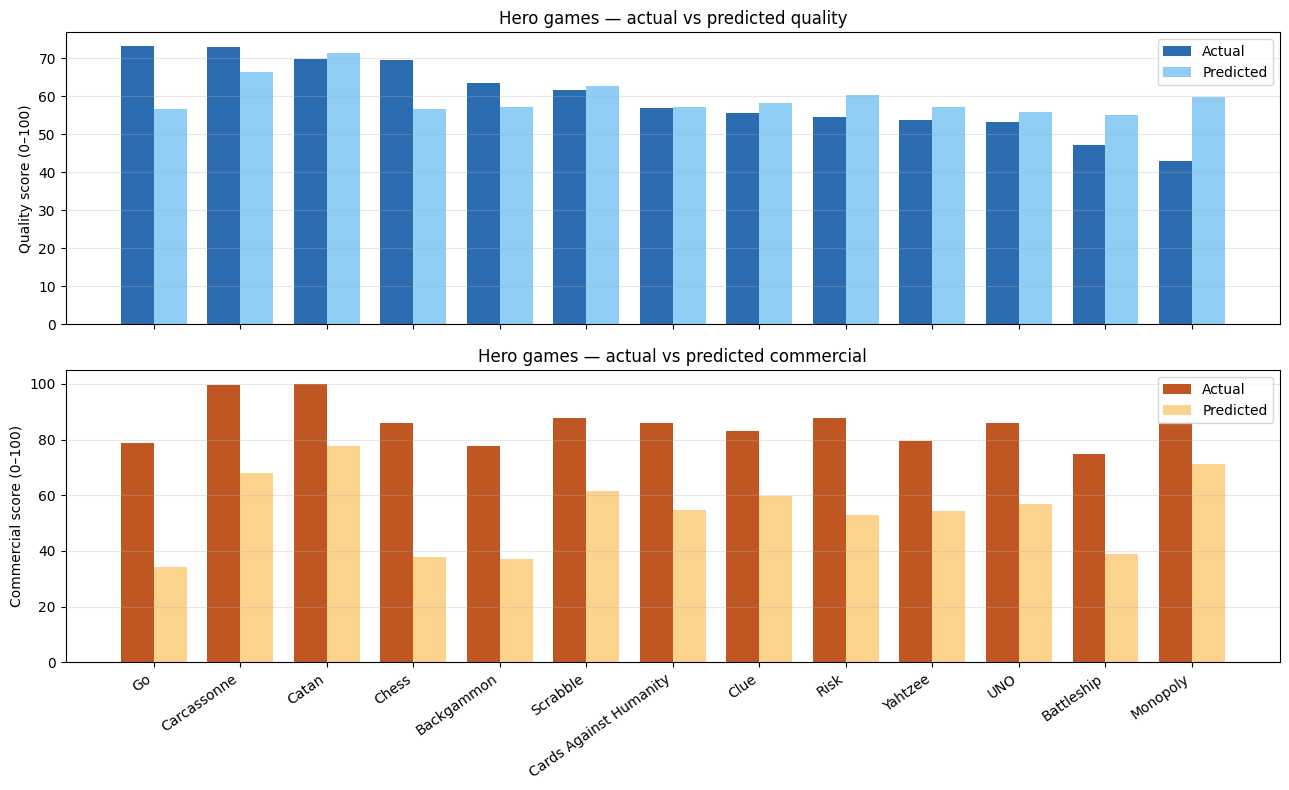

                  Game  BGGId  actual_quality  pred_quality  actual_commercial  pred_commercial  err_quality  err_commercial
                    Go    188         73.1794     56.536951          78.864574        34.108945   -16.642449      -44.755629
           Carcassonne    822         73.0890     66.450865          99.571806        67.916114    -6.638135      -31.655692
                 Catan     13         69.7148     71.366384          99.947596        77.630607     1.651584      -22.316988
                 Chess    171         69.6557     56.711144          86.087232        37.695422   -12.944556      -48.391810
            Backgammon   2397         63.6307     57.069114          77.523072        37.112258    -6.561586      -40.410814
              Scrabble    320         61.6004     62.780224          87.816401        61.416282     1.179824      -26.400119
Cards Against Humanity  50381         56.9854     57.206071          85.833036        54.709687     0.220671      -31.123349


In [3]:
pred_q = quality_model.predict(hero_X)
pred_c = commercial_model.predict(hero_X)

summary = pd.DataFrame({
    "Game": hero_names,
    "BGGId": hero_df["BGGId"].values,
    "actual_quality": hero_df["quality_score"].values,
    "pred_quality": pred_q,
    "actual_commercial": hero_df["commercial_score"].values,
    "pred_commercial": pred_c,
})
summary["err_quality"] = summary["pred_quality"] - summary["actual_quality"]
summary["err_commercial"] = summary["pred_commercial"] - summary["actual_commercial"]
summary = summary.sort_values("actual_quality", ascending=False).reset_index(drop=True)
summary.to_csv(FIG_DIR / "fig01_dual_prediction_data.csv", index=False)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
x = np.arange(len(summary))
w = 0.38

axes[0].bar(x - w/2, summary["actual_quality"], w, label="Actual", color="#2b6cb0")
axes[0].bar(x + w/2, summary["pred_quality"], w, label="Predicted", color="#90cdf4")
axes[0].set_ylabel("Quality score (0–100)")
axes[0].set_title("Hero games — actual vs predicted quality")
axes[0].legend(loc="upper right")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(x - w/2, summary["actual_commercial"], w, label="Actual", color="#c05621")
axes[1].bar(x + w/2, summary["pred_commercial"], w, label="Predicted", color="#fbd38d")
axes[1].set_ylabel("Commercial score (0–100)")
axes[1].set_title("Hero games — actual vs predicted commercial")
axes[1].legend(loc="upper right")
axes[1].grid(axis="y", alpha=0.3)

axes[1].set_xticks(x)
axes[1].set_xticklabels(summary["Game"], rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_dual_prediction_summary.png", dpi=130, bbox_inches="tight")
plt.show()
print(summary.to_string(index=False))


## Figure 2 — SHAP waterfalls (26 = 13 games × 2 models)

One waterfall per (game, model). Top 15 contributing features; remainder
collapsed into "other features". Human-readable labels.


In [4]:
import shap

explainer_q = shap.TreeExplainer(quality_model)
explainer_c = shap.TreeExplainer(commercial_model)

shap_q = explainer_q.shap_values(hero_X)
shap_c = explainer_c.shap_values(hero_X)
base_q = explainer_q.expected_value
base_c = explainer_c.expected_value
if isinstance(base_q, (list, np.ndarray)) and not np.isscalar(base_q):
    base_q = float(np.array(base_q).ravel()[0])
if isinstance(base_c, (list, np.ndarray)) and not np.isscalar(base_c):
    base_c = float(np.array(base_c).ravel()[0])
print(f"Base values: quality={base_q:.2f}  commercial={base_c:.2f}")
print(f"SHAP shapes: q={shap_q.shape} c={shap_c.shape}")


/Users/lucaban/ghq/github.com/craftingtablestudio/ludometrics/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Base values: quality=56.85  commercial=39.81
SHAP shapes: q=(13, 400) c=(13, 400)


### Catan — Quality prediction
  base value             56.85
  predicted score        71.37
  total SHAP shift      +14.52
  top contributions (signed):
     +4.866  [   has]  Category — Strategy
     +2.827  [   has]  Income
     +1.995  [ =8.80]  ComAgeRec
     +1.987  [   has]  Category — Family
     +1.567  [   has]  Variable Set-up
     +0.628  [   has]  Network and Route Building
     +0.518  [   has]  Race
     +0.470  [ =2.31]  GameWeight
     +0.287  [   has]  Hexagon Grid
     +0.242  [=120.00]  MfgPlaytime
     -0.142  [=60.00]  ComMinPlaytime
     +0.118  [ =3.00]  MinPlayers
     -0.115  [absent]  Set Collection
     -0.101  [absent]  Drafting
     +0.095  [   has]  Modular Board
     -0.723  [+385 other features collapsed]


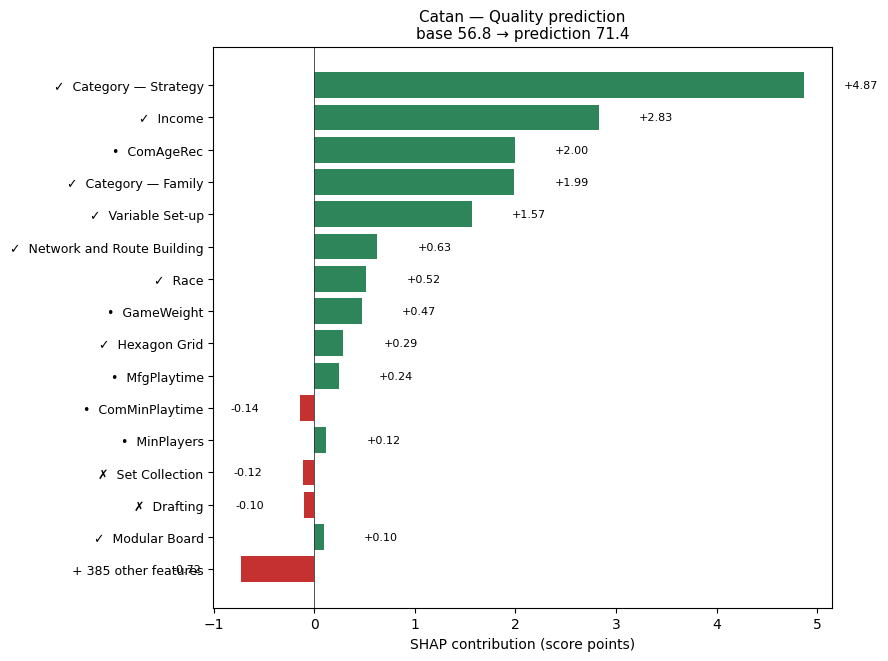

### Catan — Commercial prediction
  base value             39.81
  predicted score        77.63
  total SHAP shift      +37.83
  top contributions (signed):
     +9.597  [   has]  Category — Strategy
     +7.889  [   has]  Category — Family
     +4.768  [   has]  Income
     +4.141  [ =8.80]  ComAgeRec
     +3.472  [   has]  Variable Set-up
     +2.324  [   has]  Network and Route Building
     +2.274  [ =2.31]  GameWeight
     +1.922  [   has]  Race
     +1.606  [=120.00]  MfgPlaytime
     +1.337  [   has]  Trading
     +1.174  [   has]  Hexagon Grid
     +0.436  [   has]  Negotiation
     -0.415  [absent]  Hand Management
     -0.331  [ =3.00]  MinPlayers
     -0.281  [absent]  Variable Player Powers
     -2.089  [+385 other features collapsed]


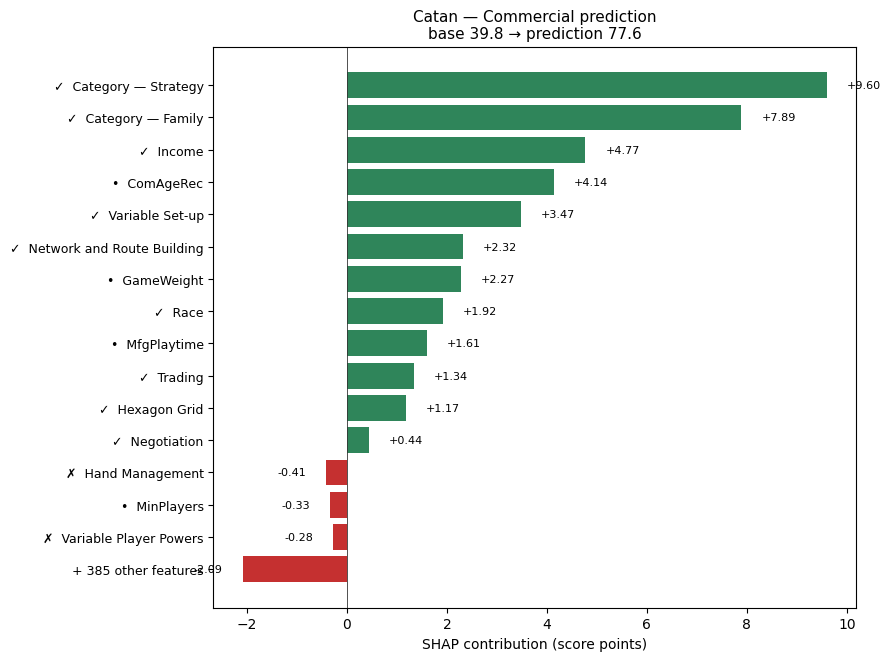

### Chess — Quality prediction
  base value             56.85
  predicted score        56.71
  total SHAP shift       -0.14
  top contributions (signed):
     +0.729  [ =3.69]  GameWeight
     -0.340  [absent]  Category — Strategy
     +0.264  [   has]  Category — Abstract
     -0.168  [absent]  Category — Family
     +0.168  [   has]  Grid Movement
     +0.140  [ =2.00]  MaxPlayers
     -0.139  [ =6.00]  MfgAgeRec
     -0.131  [absent]  Hand Management
     +0.119  [   has]  Square Grid
     -0.100  [absent]  Category — Thematic
     -0.057  [ =7.04]  ComAgeRec
     -0.049  [absent]  Drafting
     -0.045  [absent]  Campaign / Battle Card Driven
     -0.044  [absent]  Variable Player Powers
     -0.044  [absent]  Solo / Solitaire Game
     -0.439  [+385 other features collapsed]


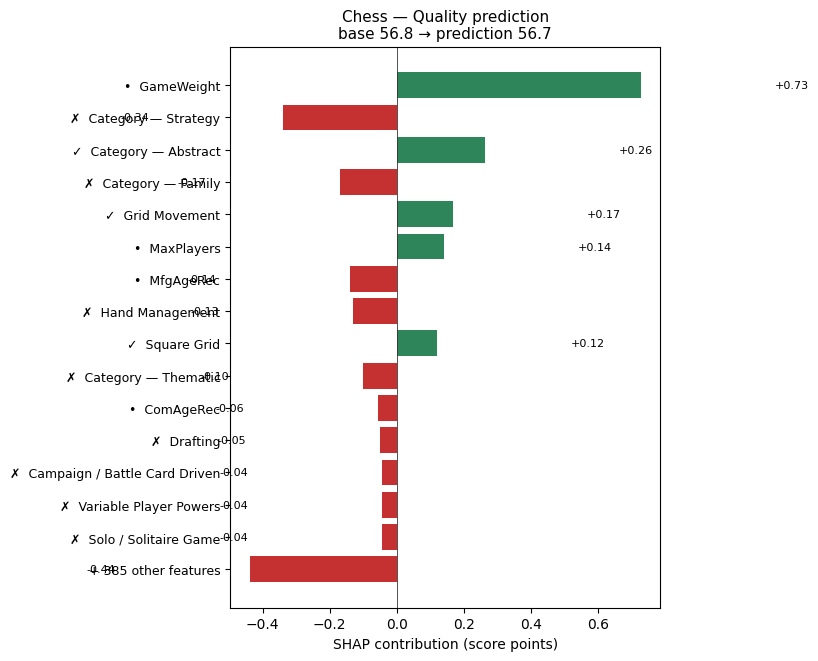

### Chess — Commercial prediction
  base value             39.81
  predicted score        37.70
  total SHAP shift       -2.11
  top contributions (signed):
     -2.649  [ =6.00]  MfgAgeRec
     +2.276  [   has]  Square Grid
     +2.192  [   has]  Grid Movement
     +2.153  [ =7.04]  ComAgeRec
     -1.053  [absent]  Category — Strategy
     -0.824  [ =3.69]  GameWeight
     -0.684  [absent]  Category — Family
     +0.681  [ =2.00]  MaxPlayers
     -0.594  [absent]  Hand Management
     -0.480  [absent]  Category — Thematic
     -0.427  [=60.00]  ComMinPlaytime
     -0.307  [absent]  Variable Player Powers
     -0.268  [absent]  Category — Party
     -0.256  [absent]  Solo / Solitaire Game
     -0.130  [absent]  Category — War
     -1.740  [+385 other features collapsed]


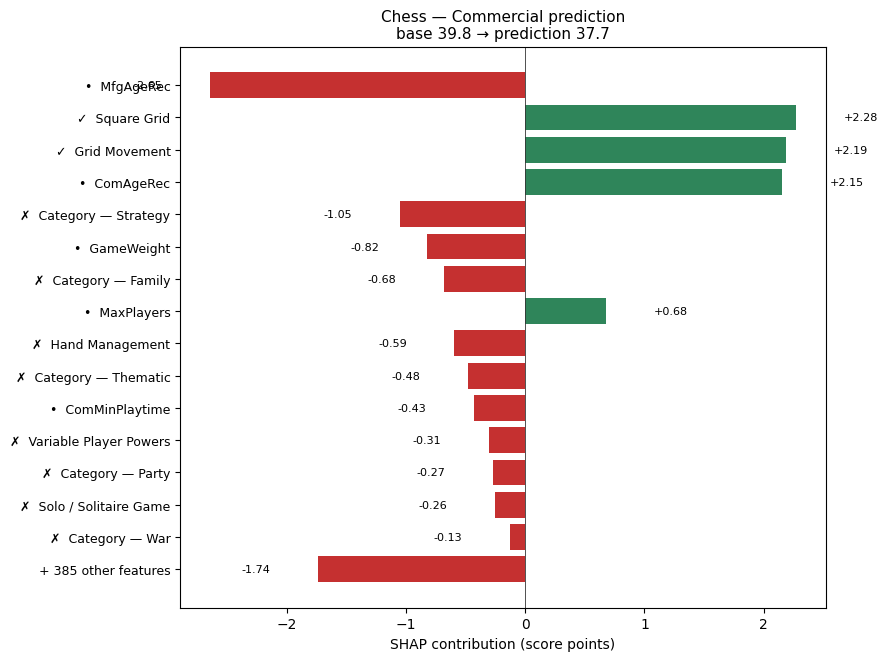

### Risk — Quality prediction
  base value             56.85
  predicted score        60.40
  total SHAP shift       +3.56
  top contributions (signed):
     +2.167  [ =8.83]  ComAgeRec
     +2.015  [   has]  Category — Family
     +0.688  [ =2.08]  GameWeight
     -0.434  [=120.00]  ComMinPlaytime
     +0.400  [   has]  Player Elimination
     -0.210  [ =6.00]  MaxPlayers
     -0.198  [absent]  Category — Strategy
     -0.137  [absent]  Drafting
     -0.115  [absent]  Solo / Solitaire Game
     -0.088  [absent]  Hand Management
     -0.082  [   has]  Category — War
     +0.064  [absent]  Roll / Spin and Move
     +0.061  [=120.00]  MfgPlaytime
     +0.054  [   has]  Sub — Territory Building
     -0.051  [absent]  Betting and Bluffing
     -0.580  [+385 other features collapsed]


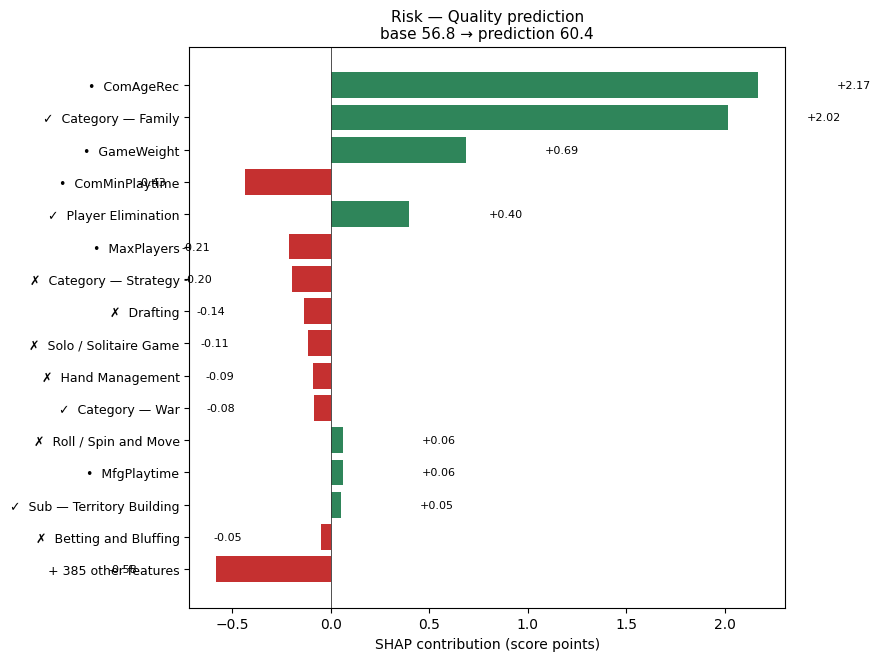

### Risk — Commercial prediction
  base value             39.81
  predicted score        53.06
  total SHAP shift      +13.25
  top contributions (signed):
    +10.608  [   has]  Category — Family
     +3.914  [ =8.83]  ComAgeRec
     +2.452  [   has]  Player Elimination
     +1.846  [ =2.08]  GameWeight
     -1.435  [=120.00]  ComMinPlaytime
     -0.602  [absent]  Category — Strategy
     -0.598  [ =6.00]  MaxPlayers
     +0.548  [   has]  Set Collection
     -0.435  [absent]  Hand Management
     +0.368  [   has]  Sub — Territory Building
     -0.343  [absent]  Drafting
     -0.298  [absent]  Solo / Solitaire Game
     +0.264  [=120.00]  MfgPlaytime
     -0.256  [absent]  Category — Thematic
     -0.182  [absent]  Cooperative Game
     -2.598  [+385 other features collapsed]


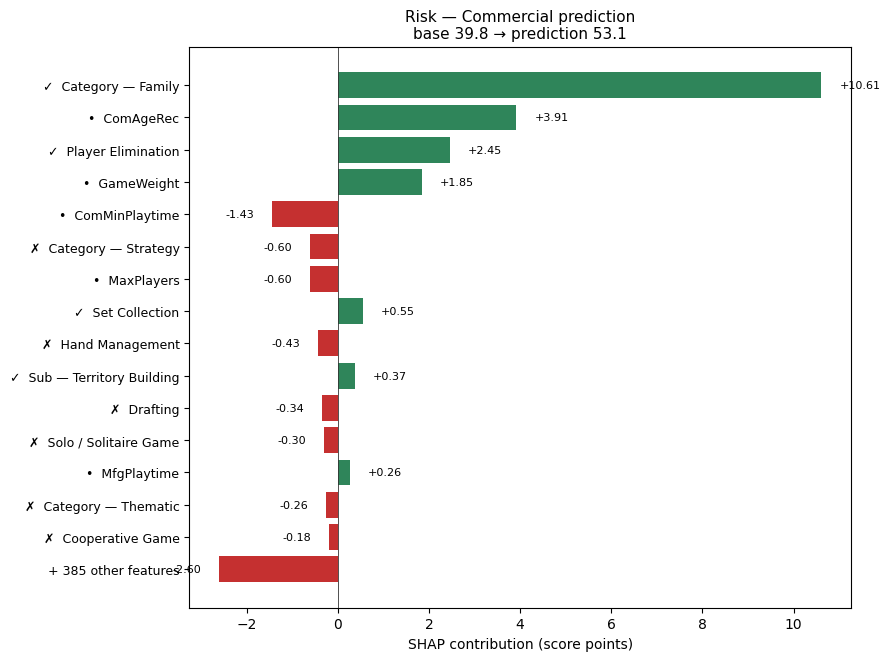

### Go — Quality prediction
  base value             56.85
  predicted score        56.54
  total SHAP shift       -0.31
  top contributions (signed):
     +0.687  [ =3.94]  GameWeight
     -0.444  [absent]  Category — Strategy
     +0.398  [   has]  Category — Abstract
     -0.276  [ =6.61]  ComAgeRec
     +0.236  [=180.00]  MfgPlaytime
     -0.174  [absent]  Category — Family
     -0.157  [absent]  Hand Management
     +0.145  [   has]  Enclosure
     +0.132  [ =2.00]  MaxPlayers
     -0.106  [absent]  Category — Thematic
     -0.089  [ =8.00]  MfgAgeRec
     -0.067  [absent]  Variable Player Powers
     +0.063  [   has]  Square Grid
     -0.058  [absent]  Solo / Solitaire Game
     -0.057  [absent]  Tile Placement
     -0.541  [+385 other features collapsed]


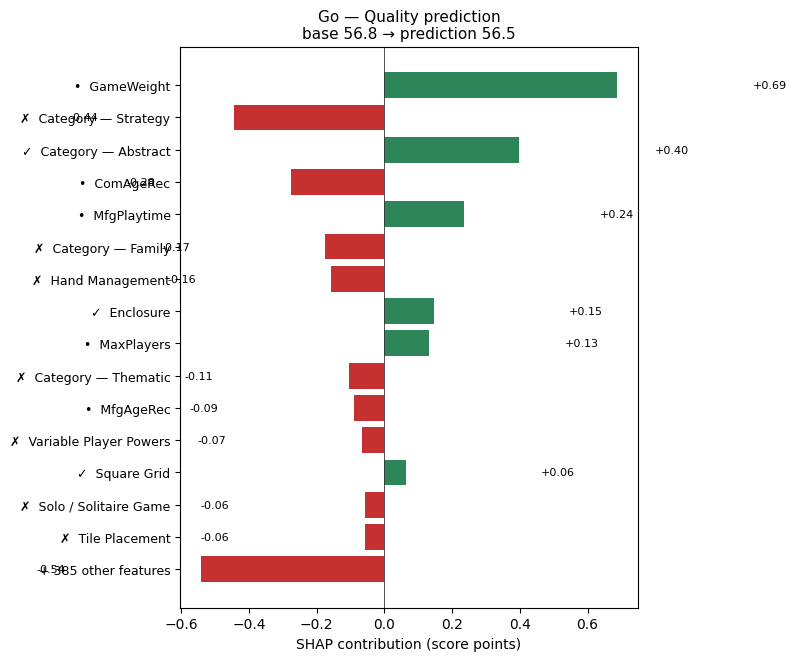

### Go — Commercial prediction
  base value             39.81
  predicted score        34.11
  total SHAP shift       -5.70
  top contributions (signed):
     +2.371  [   has]  Square Grid
     -1.289  [ =3.94]  GameWeight
     -1.245  [absent]  Category — Strategy
     -1.000  [absent]  Category — Family
     +0.921  [=180.00]  MfgPlaytime
     +0.814  [ =6.61]  ComAgeRec
     -0.698  [ =8.00]  MfgAgeRec
     -0.605  [absent]  Hand Management
     -0.508  [absent]  Category — Thematic
     -0.473  [ =2.00]  MaxPlayers
     -0.304  [   has]  Enclosure
     -0.296  [absent]  Category — Party
     -0.289  [absent]  Variable Player Powers
     -0.289  [absent]  Grid Movement
     -0.266  [absent]  Solo / Solitaire Game
     -2.540  [+385 other features collapsed]


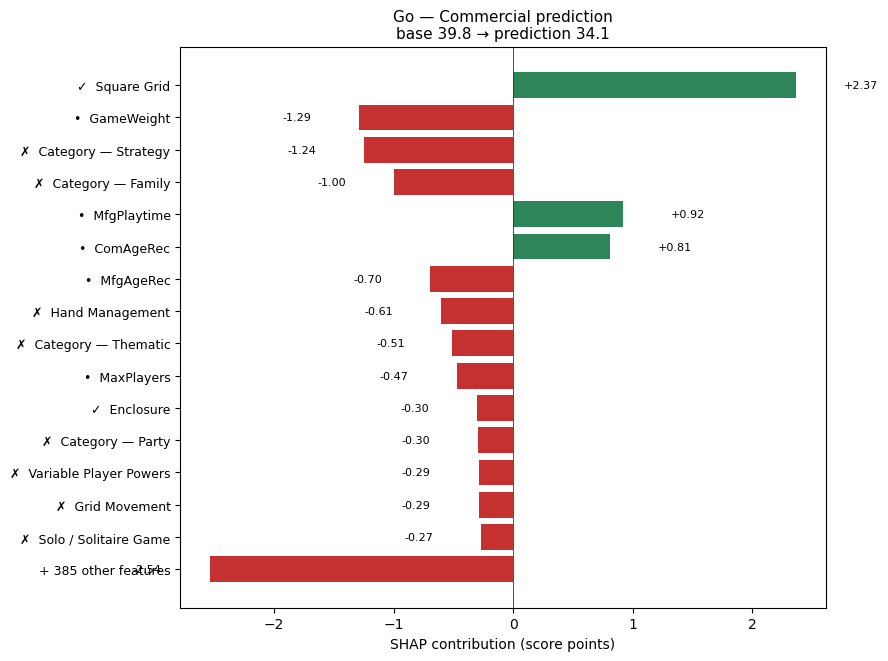

### Scrabble — Quality prediction
  base value             56.85
  predicted score        62.78
  total SHAP shift       +5.93
  top contributions (signed):
     +2.669  [   has]  End Game Bonuses
     +2.514  [ =9.32]  ComAgeRec
     +1.965  [   has]  Category — Family
     +0.454  [ =2.09]  GameWeight
     -0.319  [absent]  Category — Strategy
     -0.290  [=90.00]  ComMinPlaytime
     -0.226  [=10.00]  MfgAgeRec
     -0.200  [absent]  Set Collection
     -0.140  [absent]  Drafting
     -0.129  [   has]  Sub — Word Game
     +0.119  [   has]  Hand Management
     -0.088  [absent]  Solo / Solitaire Game
     +0.051  [absent]  Roll / Spin and Move
     +0.045  [absent]  Dice Rolling
     -0.041  [absent]  Cooperative Game
     -0.452  [+385 other features collapsed]


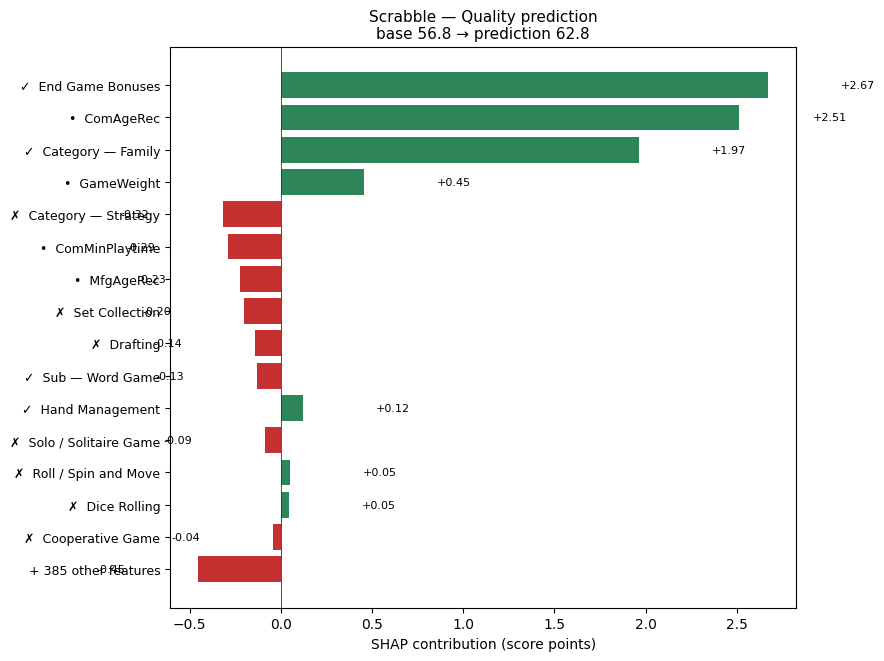

### Scrabble — Commercial prediction
  base value             39.81
  predicted score        61.42
  total SHAP shift      +21.61
  top contributions (signed):
    +10.469  [   has]  Category — Family
     +7.863  [   has]  End Game Bonuses
     +4.803  [ =9.32]  ComAgeRec
     +1.604  [ =2.09]  GameWeight
     +0.944  [   has]  Hand Management
     -0.935  [=90.00]  ComMinPlaytime
     -0.911  [absent]  Category — Strategy
     +0.786  [=90.00]  MfgPlaytime
     +0.720  [   has]  Square Grid
     -0.392  [=10.00]  MfgAgeRec
     -0.375  [absent]  Set Collection
     -0.301  [absent]  Drafting
     -0.205  [absent]  Category — Thematic
     +0.188  [ =2.00]  MinPlayers
     -0.184  [absent]  Cooperative Game
     -2.463  [+385 other features collapsed]


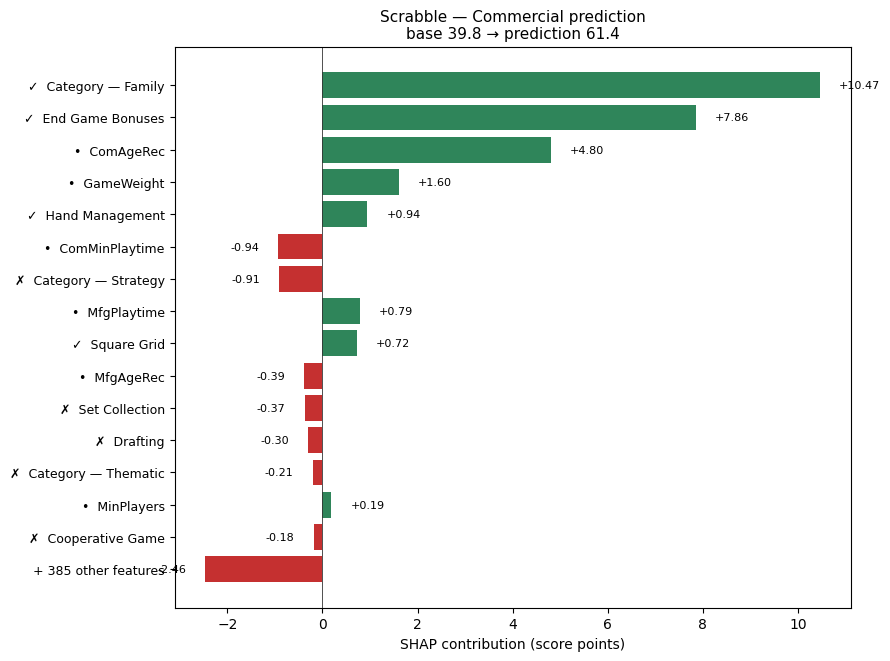

### Carcassonne — Quality prediction
  base value             56.85
  predicted score        66.45
  total SHAP shift       +9.60
  top contributions (signed):
     +2.593  [   has]  Map Addition
     +2.248  [   has]  Category — Family
     +1.965  [ =7.52]  ComAgeRec
     +1.011  [ =1.91]  GameWeight
     +0.750  [   has]  Tile Placement
     +0.618  [   has]  Theme (broad) — Medieval
     +0.531  [   has]  Theme (broad) — City Building
     +0.415  [   has]  Area Majority / Influence
     -0.243  [ =7.00]  MfgAgeRec
     +0.132  [=30.00]  ComMinPlaytime
     -0.118  [absent]  Category — Strategy
     -0.116  [absent]  Drafting
     -0.107  [absent]  Solo / Solitaire Game
     +0.098  [   has]  Sub — Territory Building
     +0.069  [=45.00]  MfgPlaytime
     -0.245  [+385 other features collapsed]


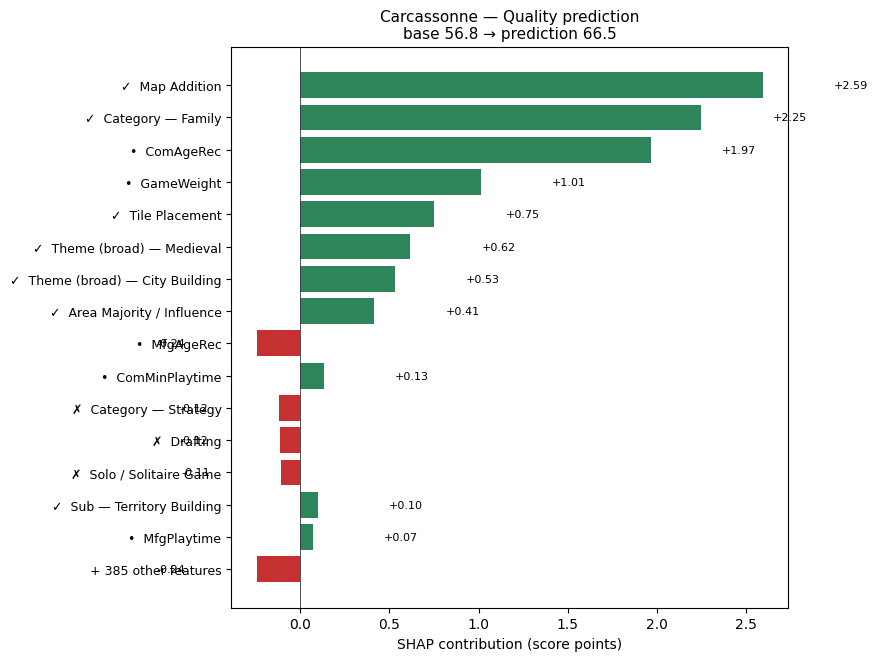

### Carcassonne — Commercial prediction
  base value             39.81
  predicted score        67.92
  total SHAP shift      +28.11
  top contributions (signed):
    +10.350  [   has]  Category — Family
     +6.735  [   has]  Map Addition
     +6.048  [ =7.52]  ComAgeRec
     +3.654  [ =1.91]  GameWeight
     +2.025  [   has]  Theme (broad) — City Building
     +1.671  [   has]  Tile Placement
     -1.406  [ =7.00]  MfgAgeRec
     +0.770  [   has]  Theme (broad) — Medieval
     +0.765  [   has]  Area Majority / Influence
     +0.455  [   has]  Sub — Territory Building
     -0.436  [absent]  Category — Strategy
     -0.322  [absent]  Drafting
     -0.299  [ =5.00]  MaxPlayers
     -0.256  [absent]  Solo / Solitaire Game
     -0.232  [absent]  Category — Thematic
     -1.412  [+385 other features collapsed]


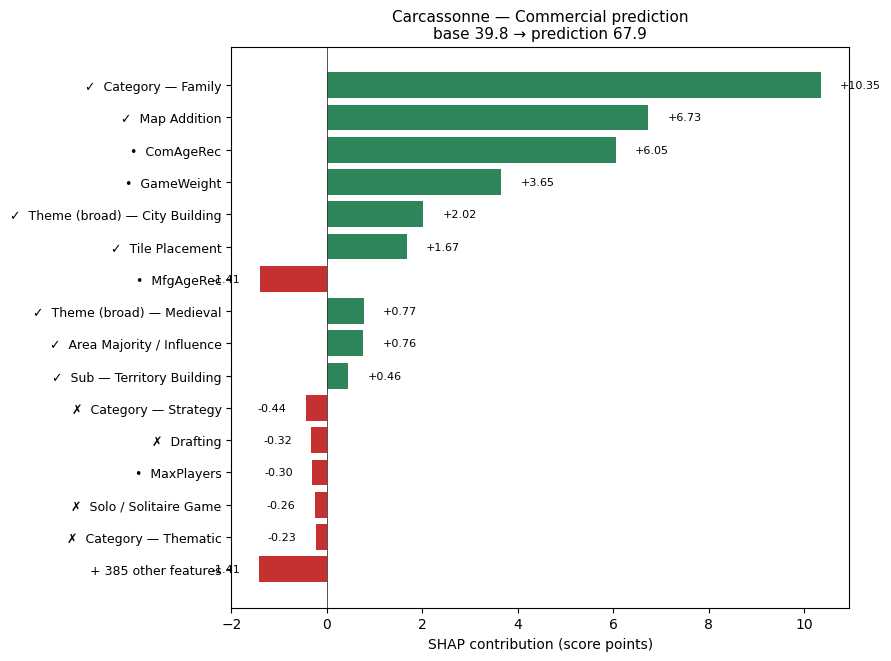

### Clue — Quality prediction
  base value             56.85
  predicted score        58.35
  total SHAP shift       +1.51
  top contributions (signed):
     +2.199  [ =8.13]  ComAgeRec
     +1.408  [   has]  Category — Family
     -0.773  [   has]  Roll / Spin and Move
     -0.325  [ =1.66]  GameWeight
     -0.254  [absent]  Category — Strategy
     +0.248  [   has]  Deduction
     +0.198  [   has]  Grid Movement
     -0.131  [absent]  Drafting
     -0.130  [   has]  Theme (broad) — Movies / TV / Radio theme
     -0.125  [absent]  Solo / Solitaire Game
     -0.123  [=45.00]  ComMinPlaytime
     +0.114  [   has]  Theme (broad) — Murder/Mystery
     -0.094  [   has]  Square Grid
     +0.077  [   has]  Betting and Bluffing
     -0.073  [absent]  Category — Thematic
     -0.708  [+385 other features collapsed]


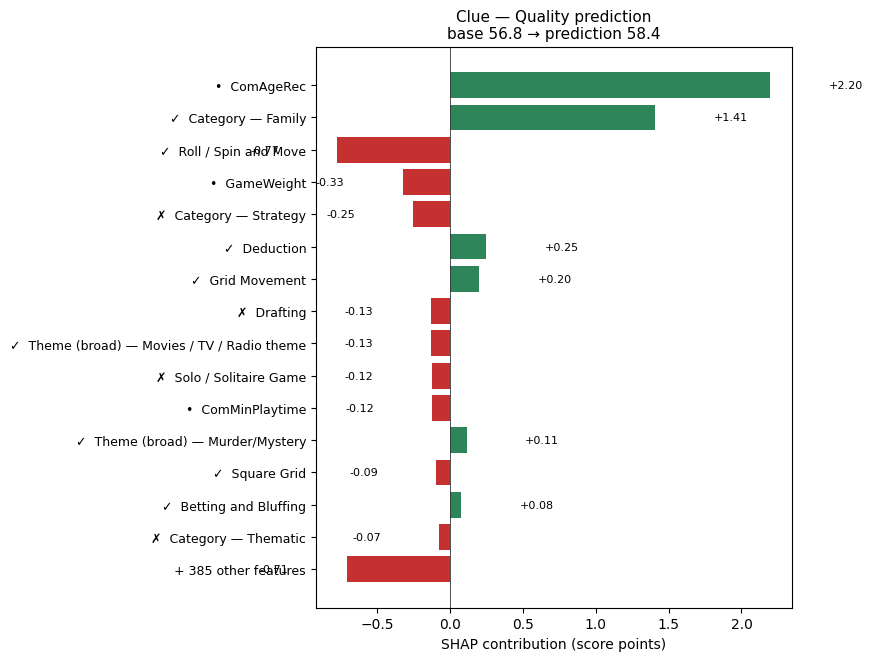

### Clue — Commercial prediction
  base value             39.81
  predicted score        59.83
  total SHAP shift      +20.03
  top contributions (signed):
    +11.470  [   has]  Category — Family
     +5.027  [ =8.13]  ComAgeRec
     +2.950  [ =1.66]  GameWeight
     +2.466  [   has]  Deduction
     +1.424  [   has]  Theme (broad) — Murder/Mystery
     +0.991  [   has]  Grid Movement
     +0.645  [   has]  Theme (broad) — Movies / TV / Radio theme
     -0.586  [   has]  Memory
     -0.549  [absent]  Category — Strategy
     -0.452  [=45.00]  ComMinPlaytime
     -0.399  [   has]  Betting and Bluffing
     -0.360  [ =8.00]  MfgAgeRec
     +0.335  [   has]  Roll / Spin and Move
     -0.328  [absent]  Drafting
     -0.303  [absent]  Hand Management
     -2.303  [+385 other features collapsed]


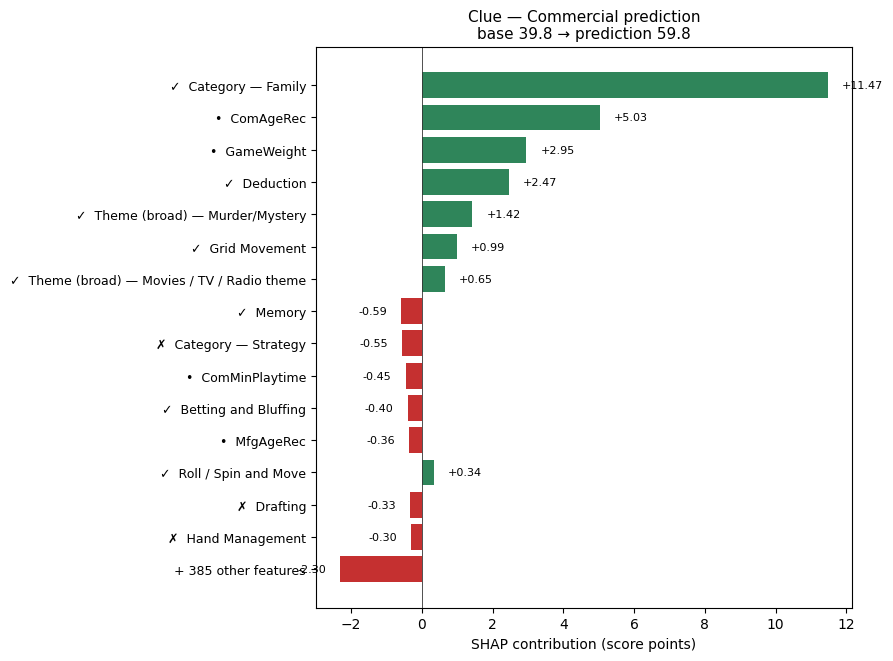

### Monopoly — Quality prediction
  base value             56.85
  predicted score        59.89
  total SHAP shift       +3.04
  top contributions (signed):
     +2.146  [ =7.73]  ComAgeRec
     +1.284  [   has]  Category — Family
     +1.155  [   has]  Track Movement
     +0.920  [   has]  Ownership
     -0.788  [   has]  Roll / Spin and Move
     -0.584  [absent]  Category — Strategy
     +0.521  [   has]  Income
     -0.472  [=60.00]  ComMinPlaytime
     -0.330  [ =1.64]  GameWeight
     +0.190  [ =8.00]  MaxPlayers
     -0.121  [absent]  Drafting
     -0.121  [absent]  Solo / Solitaire Game
     -0.110  [absent]  Hand Management
     +0.107  [   has]  Player Elimination
     -0.097  [   has]  Trading
     -0.657  [+385 other features collapsed]


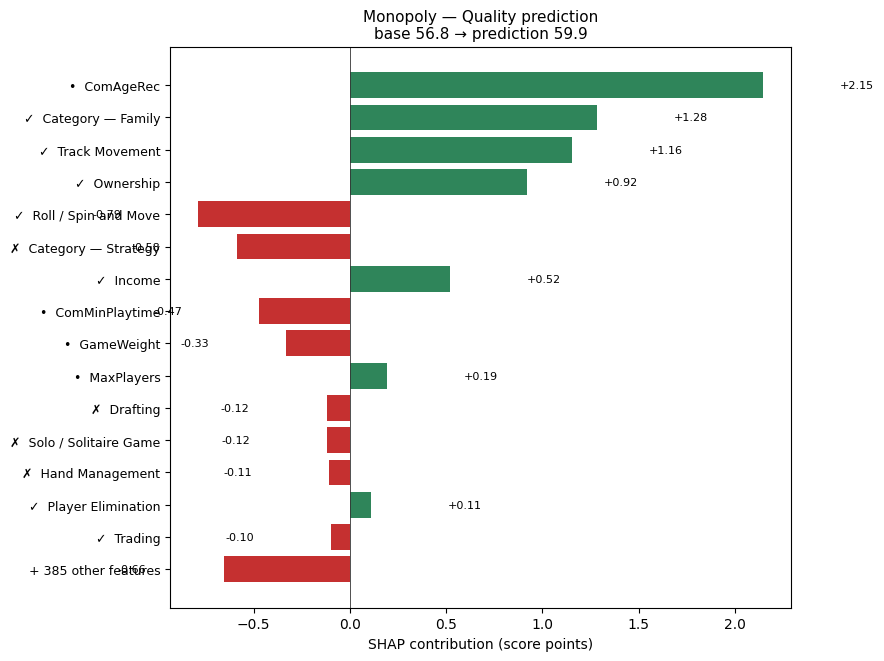

### Monopoly — Commercial prediction
  base value             39.81
  predicted score        71.26
  total SHAP shift      +31.45
  top contributions (signed):
    +14.014  [   has]  Category — Family
     +7.604  [ =7.73]  ComAgeRec
     +2.906  [ =1.64]  GameWeight
     +2.141  [   has]  Income
     +1.591  [   has]  Ownership
     +1.494  [   has]  Track Movement
     +1.430  [   has]  Set Collection
     +1.189  [   has]  Player Elimination
     -0.878  [absent]  Category — Strategy
     +0.617  [   has]  Trading
     +0.595  [ =8.00]  MaxPlayers
     +0.592  [   has]  Theme (broad) — Economic
     -0.518  [=60.00]  ComMinPlaytime
     +0.492  [ =8.00]  MfgAgeRec
     +0.449  [   has]  Auction/Bidding
     -2.267  [+385 other features collapsed]


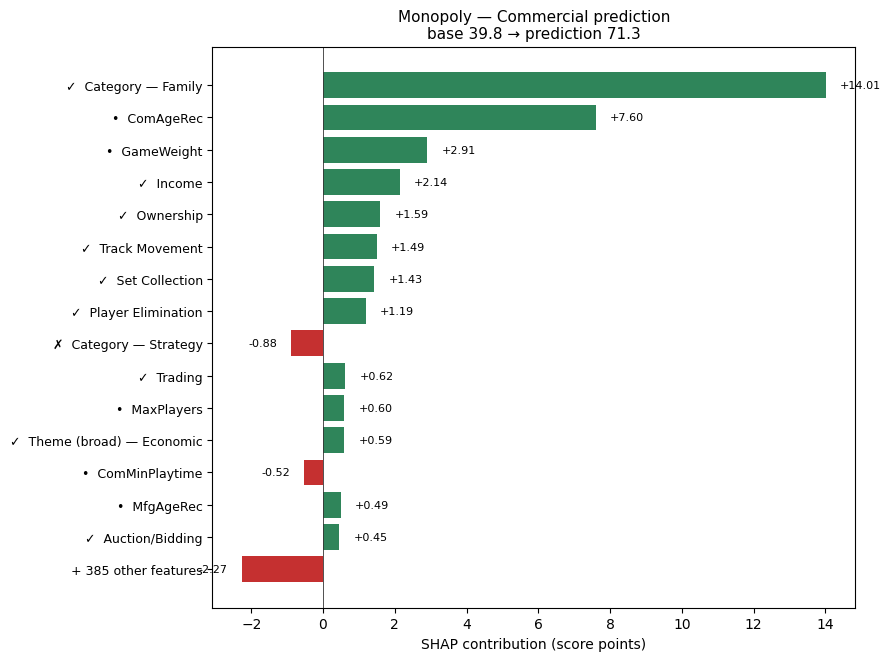

### UNO — Quality prediction
  base value             56.85
  predicted score        55.90
  total SHAP shift       -0.94
  top contributions (signed):
     +1.263  [   has]  Category — Family
     -0.674  [ =1.11]  GameWeight
     +0.340  [   has]  Take That
     -0.281  [ =6.00]  MfgAgeRec
     -0.253  [absent]  Category — Strategy
     -0.225  [ =5.35]  ComAgeRec
     -0.200  [=10.00]  MaxPlayers
     +0.153  [   has]  Hand Management
     -0.127  [absent]  Drafting
     -0.123  [absent]  Dexterity
     -0.079  [absent]  Solo / Solitaire Game
     -0.074  [   has]  Sub — Card Game
     +0.059  [absent]  Roll / Spin and Move
     -0.058  [   has]  Theme (broad) — Number
     -0.052  [=30.00]  ComMinPlaytime
     -0.612  [+385 other features collapsed]


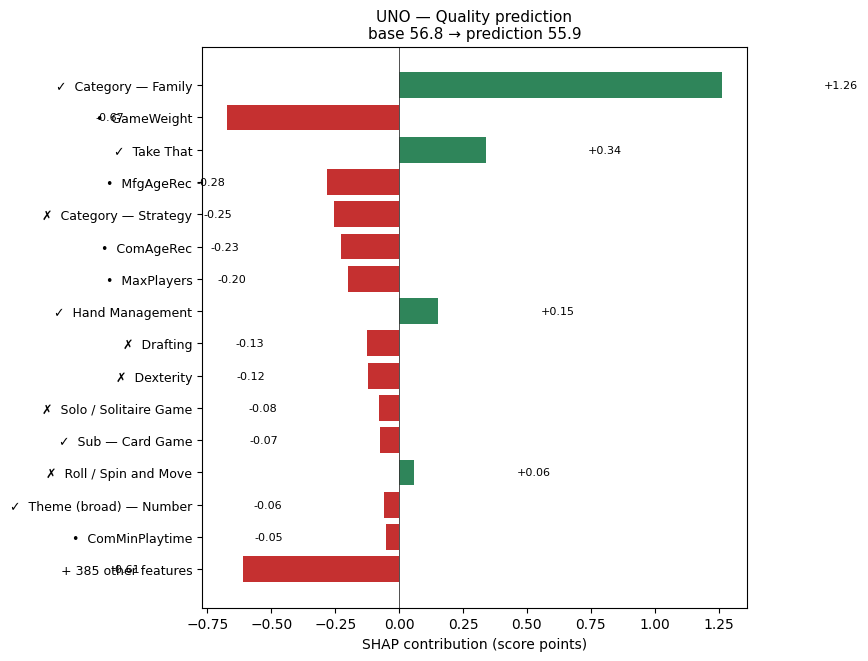

### UNO — Commercial prediction
  base value             39.81
  predicted score        56.70
  total SHAP shift      +16.90
  top contributions (signed):
     +9.282  [   has]  Category — Family
     +3.335  [ =1.11]  GameWeight
     +2.904  [   has]  Take That
     +2.652  [ =5.35]  ComAgeRec
     +1.307  [   has]  Theme (broad) — Comic Book / Strip
     +1.248  [   has]  Hand Management
     -1.218  [ =6.00]  MfgAgeRec
     +0.878  [   has]  Sub — Card Game
     +0.757  [=10.00]  MaxPlayers
     -0.656  [   has]  Theme — Anime / Manga
     -0.485  [absent]  Category — Strategy
     +0.304  [   has]  Theme (broad) — Movies / TV / Radio theme
     -0.296  [absent]  Solo / Solitaire Game
     -0.242  [=30.00]  MfgPlaytime
     -0.222  [absent]  Category — Thematic
     -2.651  [+385 other features collapsed]


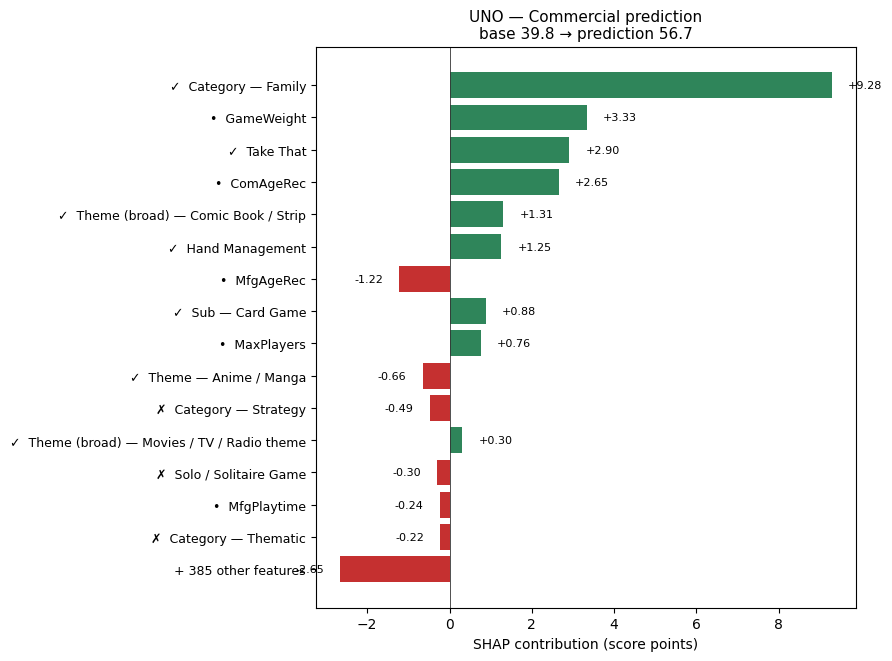

### Yahtzee — Quality prediction
  base value             56.85
  predicted score        57.09
  total SHAP shift       +0.25
  top contributions (signed):
     +1.688  [   has]  Category — Family
     -0.469  [ =1.18]  GameWeight
     +0.259  [   has]  Paper-and-Pencil
     +0.254  [ =6.42]  ComAgeRec
     -0.251  [ =6.00]  MfgAgeRec
     -0.223  [=10.00]  MaxPlayers
     +0.218  [   has]  Push Your Luck
     -0.202  [absent]  Category — Strategy
     -0.154  [   has]  Theme (broad) — Movies / TV / Radio theme
     -0.138  [absent]  Drafting
     -0.082  [absent]  Solo / Solitaire Game
     -0.080  [absent]  Dexterity
     +0.062  [absent]  Roll / Spin and Move
     -0.047  [absent]  Tile Placement
     -0.043  [absent]  Hand Management
     -0.545  [+385 other features collapsed]


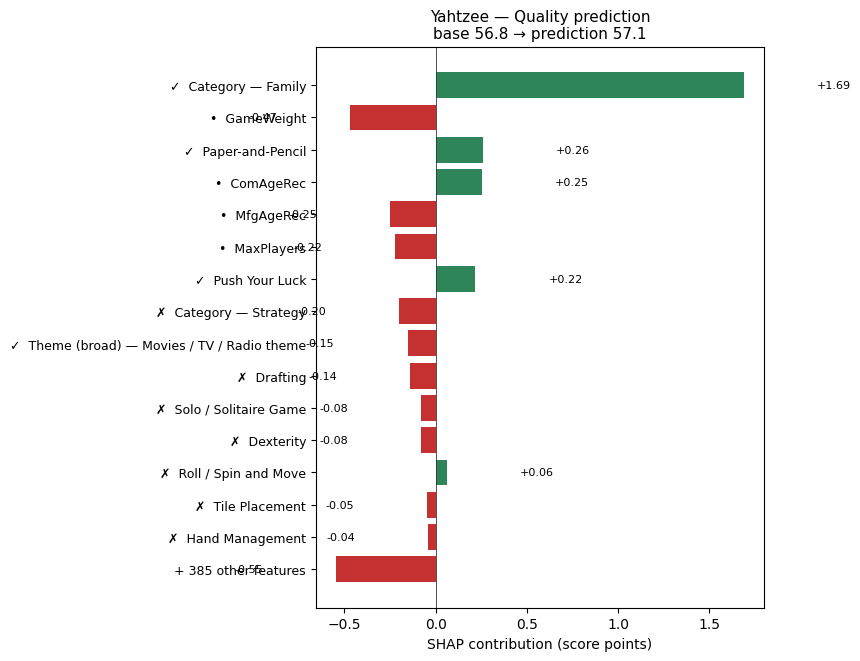

### Yahtzee — Commercial prediction
  base value             39.81
  predicted score        54.36
  total SHAP shift      +14.56
  top contributions (signed):
    +12.572  [   has]  Category — Family
     +3.061  [ =6.42]  ComAgeRec
     -2.730  [ =6.00]  MfgAgeRec
     +2.715  [   has]  Paper-and-Pencil
     +1.410  [   has]  Re-rolling and Locking
     +1.147  [ =1.18]  GameWeight
     +0.715  [=10.00]  MaxPlayers
     -0.625  [   has]  Set Collection
     -0.534  [absent]  Category — Strategy
     +0.531  [   has]  Push Your Luck
     -0.430  [absent]  Sub — Card Game
     +0.311  [   has]  Dice Rolling
     -0.307  [absent]  Solo / Solitaire Game
     -0.303  [absent]  Drafting
     -0.291  [absent]  Hand Management
     -2.682  [+385 other features collapsed]


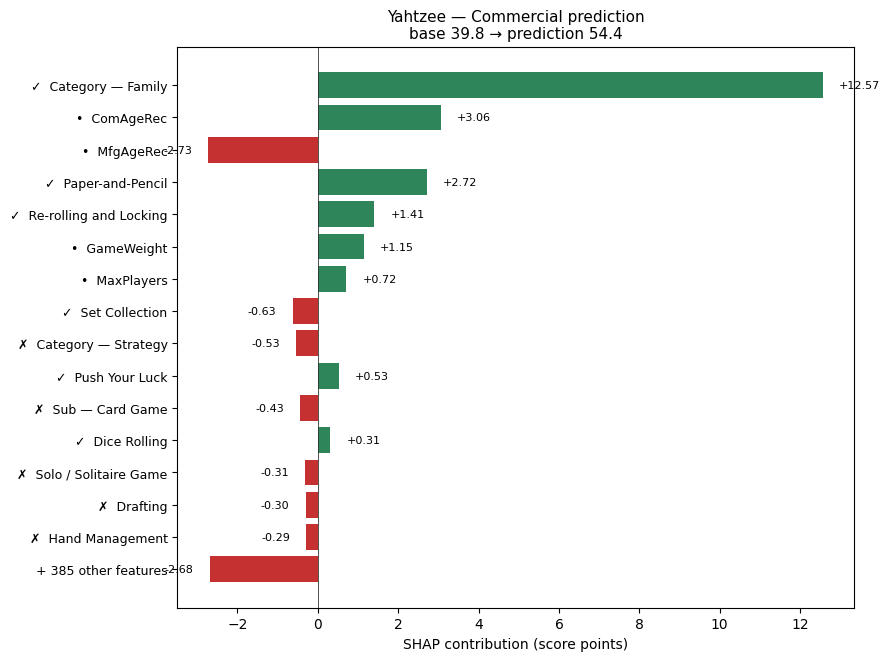

### Backgammon — Quality prediction
  base value             56.85
  predicted score        57.07
  total SHAP shift       +0.22
  top contributions (signed):
     +1.375  [   has]  Track Movement
     +0.289  [ =2.02]  GameWeight
     -0.266  [absent]  Category — Strategy
     -0.237  [   has]  Roll / Spin and Move
     -0.182  [ =7.96]  ComAgeRec
     -0.130  [absent]  Hand Management
     -0.106  [absent]  Category — Family
     +0.084  [   has]  Dice Rolling
     +0.079  [=30.00]  ComMinPlaytime
     -0.076  [=30.00]  MfgPlaytime
     -0.076  [absent]  Category — Thematic
     -0.058  [absent]  Variable Player Powers
     +0.054  [   has]  Category — Abstract
     -0.049  [absent]  Drafting
     -0.041  [absent]  Solo / Solitaire Game
     -0.439  [+385 other features collapsed]


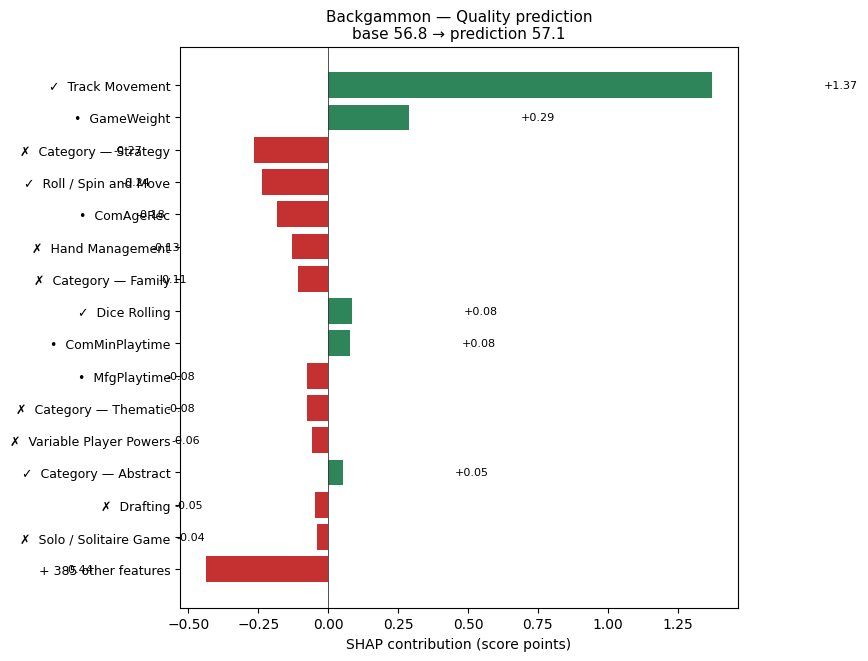

### Backgammon — Commercial prediction
  base value             39.81
  predicted score        37.11
  total SHAP shift       -2.69
  top contributions (signed):
     +3.186  [   has]  Track Movement
     +2.727  [ =2.02]  GameWeight
     -1.402  [ =7.96]  ComAgeRec
     -1.139  [absent]  Category — Strategy
     -0.940  [absent]  Category — Family
     -0.747  [=30.00]  MfgPlaytime
     -0.711  [ =8.00]  MfgAgeRec
     +0.514  [   has]  Dice Rolling
     -0.509  [absent]  Hand Management
     -0.461  [absent]  Category — Thematic
     -0.348  [absent]  Variable Player Powers
     -0.295  [absent]  Category — Party
     -0.284  [absent]  Solo / Solitaire Game
     -0.280  [   has]  Category — Abstract
     -0.189  [absent]  Set Collection
     -1.816  [+385 other features collapsed]


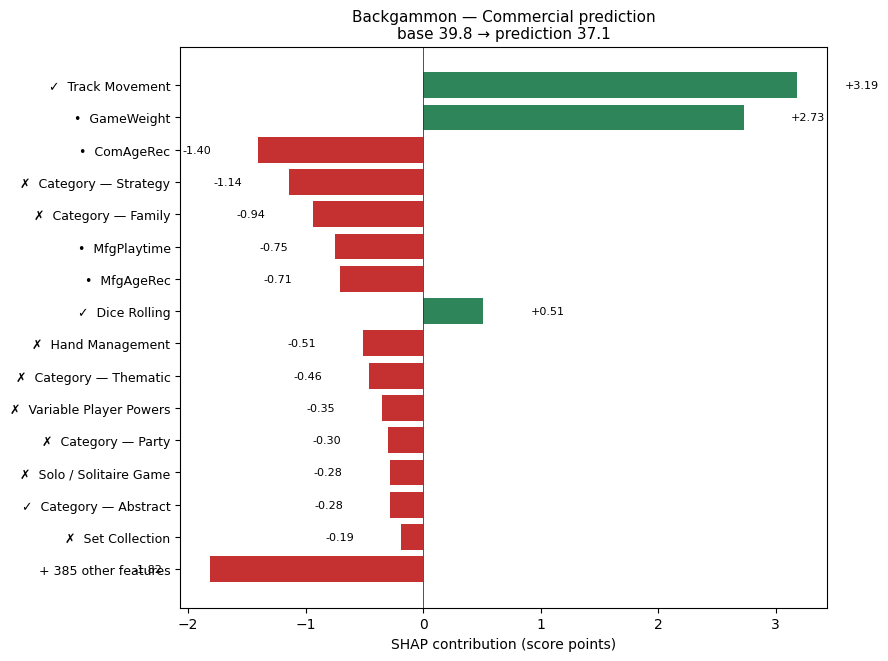

### Battleship — Quality prediction
  base value             56.85
  predicted score        55.14
  total SHAP shift       -1.71
  top contributions (signed):
     -0.306  [   has]  Category — Childrens
     -0.252  [absent]  Category — Strategy
     -0.237  [ =1.22]  GameWeight
     -0.187  [absent]  Category — Family
     -0.098  [absent]  Category — Thematic
     +0.095  [   has]  Deduction
     +0.072  [   has]  Paper-and-Pencil
     -0.062  [ =2.00]  MaxPlayers
     -0.059  [absent]  Category — Party
     -0.052  [=30.00]  ComMinPlaytime
     -0.049  [absent]  Hand Management
     -0.044  [absent]  Variable Player Powers
     -0.043  [=30.00]  MfgPlaytime
     -0.042  [absent]  Solo / Solitaire Game
     -0.036  [absent]  Drafting
     -0.411  [+385 other features collapsed]


/var/folders/jk/xkqp97lj59v6_gzp0k47cw180000gn/T/ipykernel_62067/3727179375.py:42: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


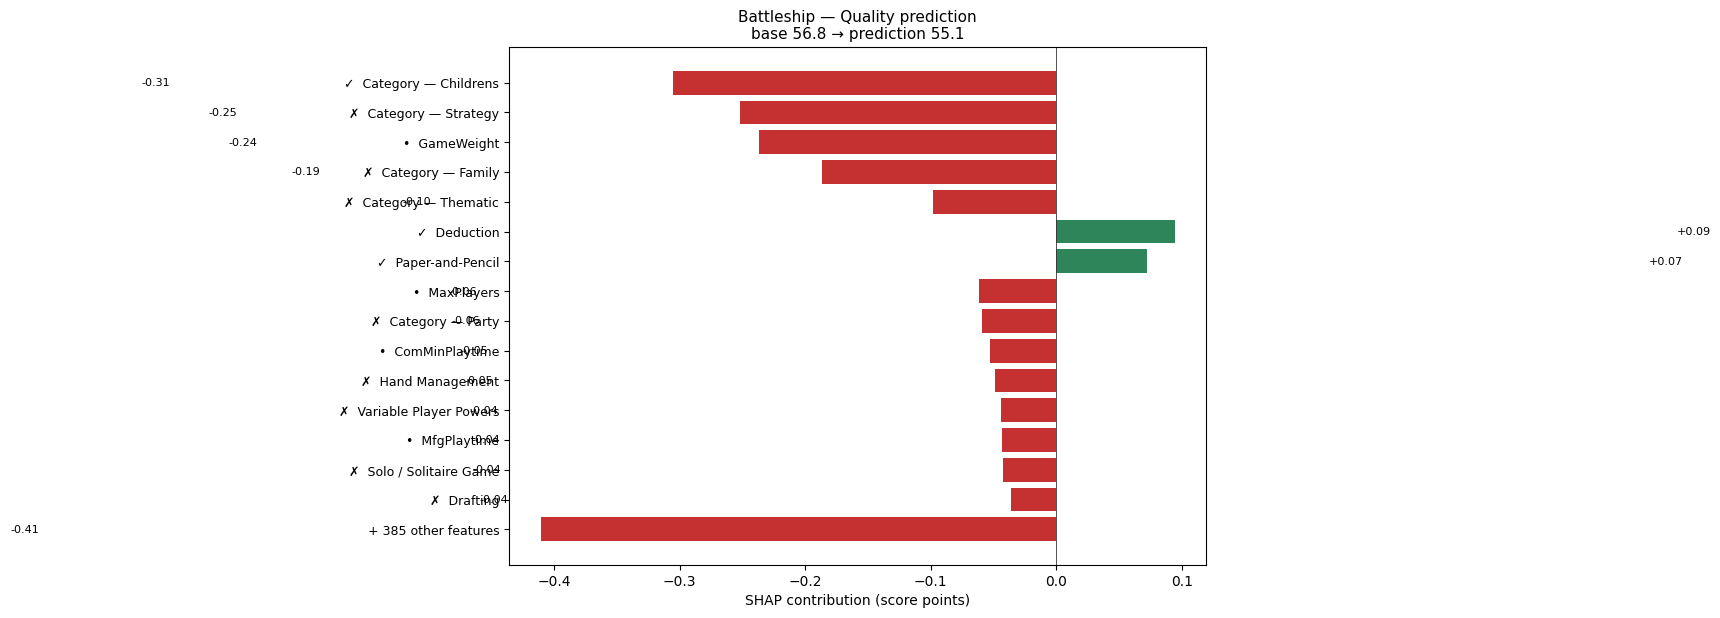

### Battleship — Commercial prediction
  base value             39.81
  predicted score        39.01
  total SHAP shift       -0.79
  top contributions (signed):
     +1.929  [ =6.14]  ComAgeRec
     +1.634  [   has]  Deduction
     -1.239  [absent]  Category — Family
     +1.210  [ =1.22]  GameWeight
     -1.037  [absent]  Category — Strategy
     +0.967  [   has]  Paper-and-Pencil
     -0.469  [absent]  Category — Thematic
     -0.417  [ =8.00]  MfgAgeRec
     -0.412  [ =2.00]  MaxPlayers
     -0.360  [absent]  Category — Party
     -0.307  [=30.00]  ComMinPlaytime
     +0.296  [   has]  Category — Childrens
     -0.227  [absent]  Hand Management
     -0.210  [absent]  Solo / Solitaire Game
     -0.187  [absent]  Variable Player Powers
     -1.966  [+385 other features collapsed]


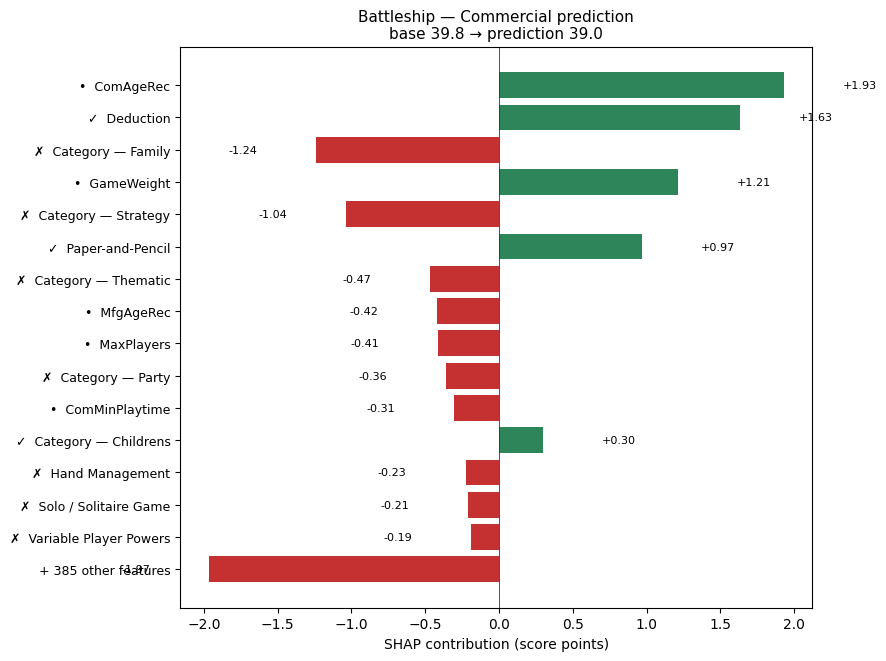

### Cards Against Humanity — Quality prediction
  base value             56.85
  predicted score        57.21
  total SHAP shift       +0.36
  top contributions (signed):
     +1.229  [   has]  Category — Party
     -0.555  [=16.72]  ComAgeRec
     +0.196  [   has]  Simultaneous Action Selection
     +0.165  [   has]  Hand Management
     +0.155  [   has]  Player Judge
     +0.143  [=20.00]  MaxPlayers
     -0.135  [absent]  Category — Strategy
     -0.098  [absent]  Communication Limits
     +0.091  [=17.00]  MfgAgeRec
     -0.086  [absent]  Hidden Roles
     -0.078  [=30.00]  MfgPlaytime
     -0.058  [   has]  Sub — Card Game
     -0.057  [absent]  Deduction
     +0.043  [   has]  Theme (broad) — Humor
     -0.043  [absent]  Category — Thematic
     -0.553  [+385 other features collapsed]


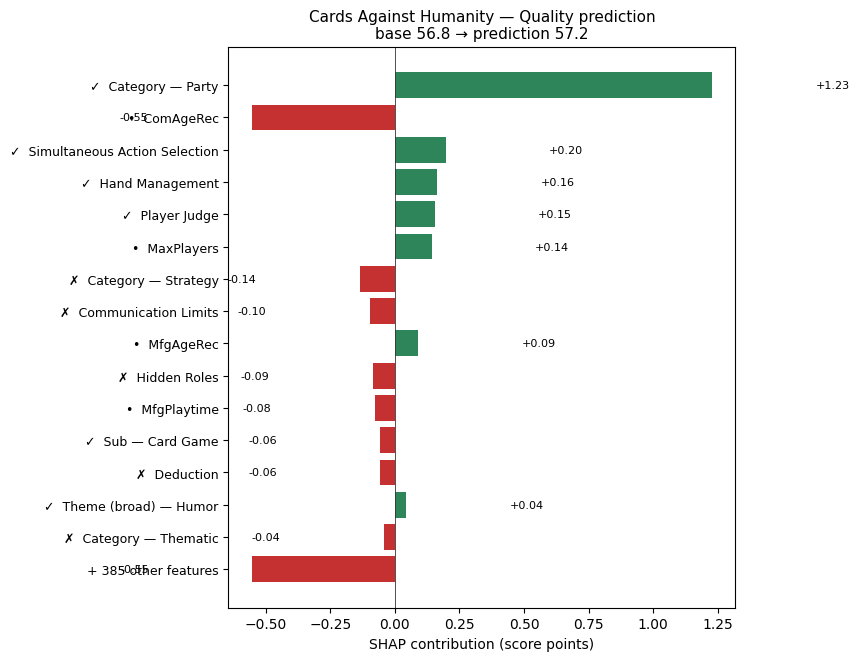

### Cards Against Humanity — Commercial prediction
  base value             39.81
  predicted score        54.71
  total SHAP shift      +14.90
  top contributions (signed):
    +12.288  [   has]  Category — Party
     -2.485  [=16.72]  ComAgeRec
     +2.200  [   has]  Player Judge
     +2.103  [=17.00]  MfgAgeRec
     +1.589  [ =1.19]  GameWeight
     -1.535  [   has]  Sub — Print & Play
     +1.466  [=20.00]  MaxPlayers
     +0.819  [   has]  Simultaneous Action Selection
     -0.670  [=30.00]  MfgPlaytime
     +0.569  [   has]  Hand Management
     -0.463  [absent]  Category — Family
     +0.435  [   has]  Theme (broad) — Mature / Adult
     +0.406  [ =4.00]  MinPlayers
     -0.300  [absent]  Category — Strategy
     +0.245  [   has]  Sub — Card Game
     -1.762  [+385 other features collapsed]


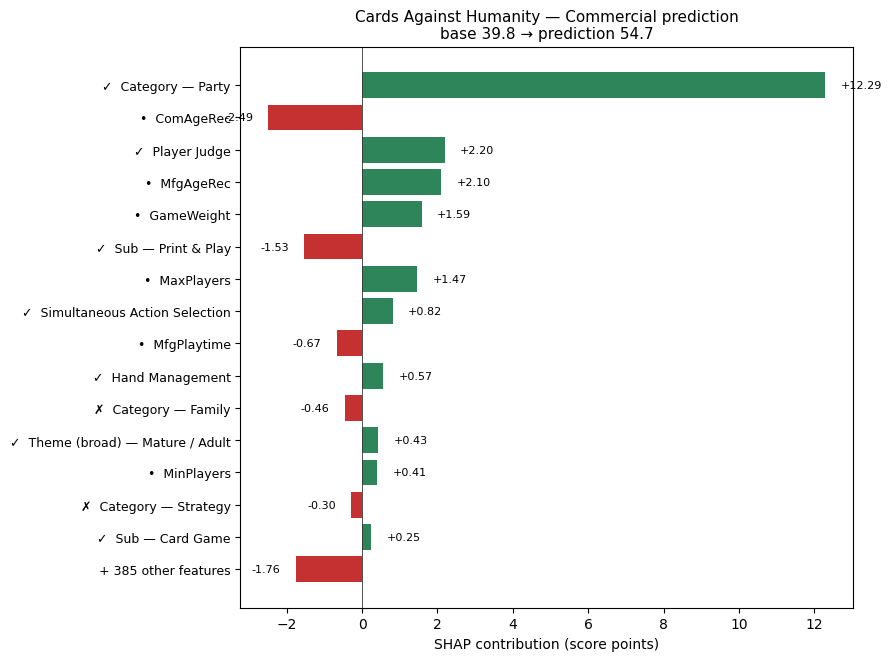


Saved 26 waterfalls.


In [5]:
def draw_waterfall(shap_row, feature_vals, base, prediction, title, out_path, top_k=15):
    feats = np.array(FEATURES)
    order = np.argsort(np.abs(shap_row))[::-1]
    top = order[:top_k]
    other = order[top_k:]
    other_sum = shap_row[other].sum() if len(other) else 0.0

    labels, contribs, presence = [], [], []
    for i in top:
        labels.append(DISPLAY[feats[i]])
        contribs.append(shap_row[i])
        presence.append(feature_vals[i])
    if len(other):
        labels.append(f"+ {len(other)} other features")
        contribs.append(other_sum)
        presence.append(None)

    # Order: largest absolute first at top of plot
    labels = labels[::-1]
    contribs = contribs[::-1]
    presence = presence[::-1]
    y = np.arange(len(labels))
    colors = ["#2f855a" if c >= 0 else "#c53030" for c in contribs]

    fig, ax = plt.subplots(figsize=(9, max(4, 0.42 * len(labels))))
    ax.barh(y, contribs, color=colors)
    ax.axvline(0, color="#333", linewidth=0.6)
    tick_labels = []
    for lab, val in zip(labels, presence):
        if val is None:
            tick_labels.append(lab)
        else:
            mark = "✓" if val == 1 else ("•" if isinstance(val, float) and val != 0 else "✗")
            tick_labels.append(f"{mark}  {lab}")
    ax.set_yticks(y)
    ax.set_yticklabels(tick_labels, fontsize=9)
    ax.set_xlabel("SHAP contribution (score points)")
    ax.set_title(f"{title}\nbase {base:.1f} → prediction {prediction:.1f}", fontsize=11)
    for yi, c in zip(y, contribs):
        ax.text(c + (0.4 if c >= 0 else -0.4), yi, f"{c:+.2f}",
                va="center", ha="left" if c >= 0 else "right", fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()

def waterfall_text(shap_row, feature_vals, base, prediction, title, top_k=15):
    """Agent-readable textual version of a SHAP waterfall."""
    feats = np.array(FEATURES)
    order = np.argsort(np.abs(shap_row))[::-1]
    top = order[:top_k]
    other = order[top_k:]
    other_sum = float(shap_row[other].sum()) if len(other) else 0.0
    lines = [f"### {title}",
             f"  base value           {base:7.2f}",
             f"  predicted score      {prediction:7.2f}",
             f"  total SHAP shift     {prediction - base:+7.2f}",
             "  top contributions (signed):"]
    for i in top:
        present = "has" if feature_vals[i] == 1 else ("absent" if feature_vals[i] == 0 else f"={feature_vals[i]:.2f}")
        lines.append(f"    {shap_row[i]:+7.3f}  [{present:>6s}]  {DISPLAY[feats[i]]}")
    lines.append(f"    {other_sum:+7.3f}  [+{len(other)} other features collapsed]")
    return "\n".join(lines)

hero_X_arr = hero_X.values
for i, game in enumerate(hero_names):
    slug = re.sub(r"[^a-z0-9]+", "_", game.lower()).strip("_")
    pred_qi = float(quality_model.predict(hero_X.iloc[[i]])[0])
    print(waterfall_text(shap_q[i], hero_X_arr[i], base_q, pred_qi,
                          f"{game} — Quality prediction"))
    draw_waterfall(shap_q[i], hero_X_arr[i], base_q, pred_qi,
                   f"{game} — Quality prediction",
                   FIG_DIR / f"fig02_shap_waterfall_{slug}_quality.png")
    pred_ci = float(commercial_model.predict(hero_X.iloc[[i]])[0])
    print(waterfall_text(shap_c[i], hero_X_arr[i], base_c, pred_ci,
                          f"{game} — Commercial prediction"))
    draw_waterfall(shap_c[i], hero_X_arr[i], base_c, pred_ci,
                   f"{game} — Commercial prediction",
                   FIG_DIR / f"fig02_shap_waterfall_{slug}_commercial.png")

print("\nSaved 26 waterfalls.")


## Figure 3 — Frankengame (Goodhart hero)

Greedy SHAP-positive feature-flipping under the **quality** model: start from
an all-zero feature vector, flip the single feature with the largest positive
SHAP contribution at each step, stop when no flip helps or at the 50-flip cap.

Continuous features (the first 8 columns: GameWeight, players, ages, playtimes)
are held at their training-set median rather than flipped, since the
"binary flip" logic only makes sense for the binary mechanic/theme/category
columns.


In [6]:
# Identify which features are binary (mechanics/themes/cats) vs continuous
CONTINUOUS_ORIG = ["GameWeight", "MinPlayers", "MaxPlayers", "ComAgeRec",
                   "MfgAgeRec", "MfgPlaytime", "ComMinPlaytime", "ComMaxPlaytime"]
CONTINUOUS_SAN = [SANITIZE(c) for c in CONTINUOUS_ORIG]
BINARY_SAN = [f for f in FEATURES if f not in CONTINUOUS_SAN]
print(f"Binary features: {len(BINARY_SAN)}  Continuous: {len(CONTINUOUS_SAN)}")

# Median continuous baseline from training data
cont_medians = train_X[CONTINUOUS_SAN].median()
print("Continuous medians:")
print(cont_medians)

# Hand-curated mutually-exclusive pairs (USER: please review/edit this list)
# Names are the ORIGINAL human-readable feature names from games_processed.csv.
# Mechanics now carry a "Mech_" prefix after 00_preprocessing.
EXCLUSIVE_PAIRS_HUMAN = [
    ("Mech_Cooperative Game", "Mech_Player Elimination"),
    ("Mech_Cooperative Game", "Mech_Alliances"),
    ("Mech_Real-Time", "Mech_Simultaneous Action Selection"),
    ("Mech_Real-Time", "Mech_Action Points"),
    ("Mech_Roll / Spin and Move", "Mech_Action Points"),
    ("Mech_Roll / Spin and Move", "Mech_Action Drafting"),
    ("Mech_Dice Rolling", "Cat:Abstract"),
    ("Mech_Auction/Bidding", "Cat:Childrens"),
    ("Mech_Trick-taking", "Mech_Tile Placement"),
    ("Mech_Hand Management", "Mech_Real-Time"),
    ("Mech_Semi-Cooperative Game", "Mech_Player Elimination"),
    ("Mech_Lose a Turn", "Mech_Simultaneous Action Selection"),
]
# Sanitize to model feature names; drop pairs whose features don't exist.
EXCLUSIVE_PAIRS = []
for a, b in EXCLUSIVE_PAIRS_HUMAN:
    sa, sb = SANITIZE(a), SANITIZE(b)
    if sa in FEATURES and sb in FEATURES:
        EXCLUSIVE_PAIRS.append((sa, sb))
    else:
        print(f"  (dropped pair, feature missing: {a} ↔ {b})")
print(f"Active exclusive pairs: {len(EXCLUSIVE_PAIRS)}")


Binary features: 392  Continuous: 8
Continuous medians:
GameWeight         2.0
MinPlayers         2.0
MaxPlayers         4.0
ComAgeRec         10.0
MfgAgeRec         10.0
MfgPlaytime       45.0
ComMinPlaytime    30.0
ComMaxPlaytime    45.0
dtype: float64
Active exclusive pairs: 12


In [7]:
def frankengame(model, cap=50):
    """Greedy maximum-flip-delta from an all-zero binary baseline.

    At each step, evaluates the actual prediction delta of flipping each
    currently-absent binary feature on (one at a time), and picks the flip
    with the largest positive delta. Stops when no flip improves the score
    or the cap is reached. This is the correct marginal-effect heuristic
    (not SHAP-at-current-state, which conflates attribution with marginal
    effect).
    """
    vec = pd.Series(0.0, index=FEATURES)
    for c in CONTINUOUS_SAN:
        vec[c] = cont_medians[c]
    bin_idx = np.array([FEATURES.index(f) for f in BINARY_SAN])
    history = []
    cur_pred = float(model.predict(vec.to_frame().T)[0])
    for step in range(cap):
        candidates_idx = bin_idx[(vec.values[bin_idx] == 0)]
        if len(candidates_idx) == 0:
            break
        # Build a (n_candidates, n_features) matrix of one-flip variants
        cand = np.tile(vec.values, (len(candidates_idx), 1))
        cand[np.arange(len(candidates_idx)), candidates_idx] = 1
        cand_df = pd.DataFrame(cand, columns=FEATURES)
        preds = model.predict(cand_df)
        deltas = preds - cur_pred
        best_local = int(np.argmax(deltas))
        if deltas[best_local] <= 0:
            break
        fi = int(candidates_idx[best_local])
        feat = FEATURES[fi]
        vec[feat] = 1
        cur_pred = float(preds[best_local])
        history.append({"step": step + 1, "feature": feat, "display": DISPLAY[feat],
                        "flip_delta": float(deltas[best_local]),
                        "running_pred": cur_pred})
    return vec, [h["feature"] for h in history], history, cur_pred

print("Building Frankengame under the quality model...")
frank_vec, frank_features, frank_history, frank_pred = frankengame(quality_model, cap=50)
print(f"Final predicted quality: {frank_pred:.2f}  ({len(frank_features)} features flipped on)")

# Count exclusive-pair conflicts
conflicts = []
for a, b in EXCLUSIVE_PAIRS:
    if frank_vec[a] == 1 and frank_vec[b] == 1:
        conflicts.append((DISPLAY[a], DISPLAY[b]))
print(f"Mutually-exclusive conflicts: {len(conflicts)}")
for a, b in conflicts:
    print(f"  • {a}  ↔  {b}")

frank_df = pd.DataFrame(frank_history)
frank_df.to_csv(FIG_DIR / "fig03_frankengame_features.csv", index=False)


Building Frankengame under the quality model...


Final predicted quality: 81.35  (50 features flipped on)
Mutually-exclusive conflicts: 0


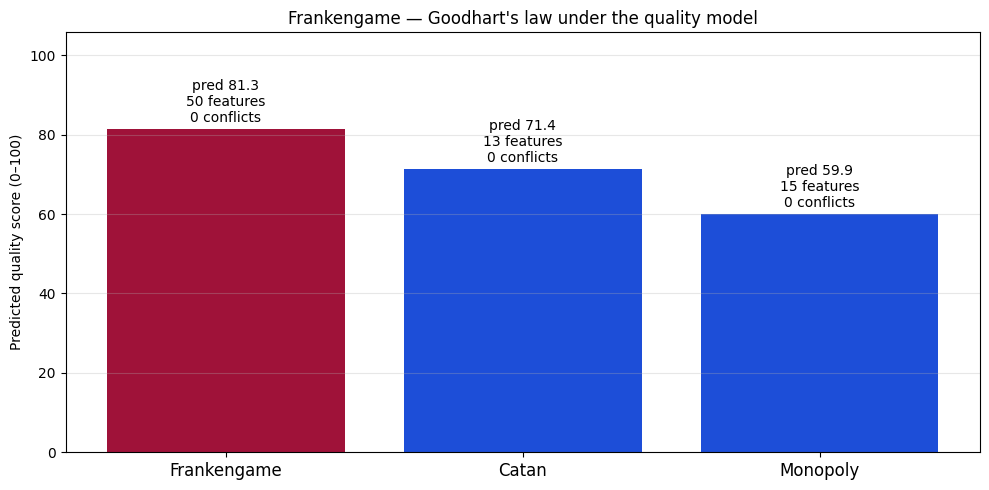


Side-by-side comparison (quality model):
  Label             Pred   Features   Conflicts
  Frankengame      81.35         50           0
  Catan            71.37         13           0
  Monopoly         59.89         15           0

Frankengame feature list:
   1. + 3.22  Grid Coverage  → pred 58.42
   2. + 1.91  Command Cards  → pred 60.34
   3. + 1.76  Bingo  → pred 62.10
   4. + 1.28  Communication Limits  → pred 63.38
   5. + 4.75  Category — Party  → pred 68.14
   6. + 1.65  Hidden Roles  → pred 69.79
   7. + 1.03  Legacy Game  → pred 70.82
   8. + 0.93  Ladder Climbing  → pred 71.75
   9. + 0.78  Theme — Spooky Old Houses  → pred 72.53
  10. + 0.77  Traitor Game  → pred 73.30
  11. + 0.71  Slide/Push  → pred 74.01
  12. + 0.62  Targeted Clues  → pred 74.63
  13. + 0.55  Speed Matching  → pred 75.18
  14. + 0.51  Theme — Construction  → pred 75.69
  15. + 0.48  Theme — Tropical  → pred 76.17
  16. + 0.42  Deduction  → pred 76.59
  17. + 0.38  Theme — Native Americans / First Peo

In [8]:
# Render Frankengame side-by-side with Catan and Monopoly
def featureset(row):
    """Return set of binary features present (display names)."""
    return {DISPLAY[f] for f in BINARY_SAN if row[f] == 1}

catan_idx = hero_names.index("Catan")
mono_idx = hero_names.index("Monopoly")
catan_row = hero_X.iloc[catan_idx]
mono_row = hero_X.iloc[mono_idx]

comparisons = [
    ("Frankengame", frank_pred, len(frank_features), len(conflicts), featureset(frank_vec)),
    ("Catan", float(quality_model.predict(catan_row.to_frame().T)[0]),
        int((catan_row[BINARY_SAN] == 1).sum()),
        sum(1 for a, b in EXCLUSIVE_PAIRS if catan_row[a] == 1 and catan_row[b] == 1),
        featureset(catan_row)),
    ("Monopoly", float(quality_model.predict(mono_row.to_frame().T)[0]),
        int((mono_row[BINARY_SAN] == 1).sum()),
        sum(1 for a, b in EXCLUSIVE_PAIRS if mono_row[a] == 1 and mono_row[b] == 1),
        featureset(mono_row)),
]

fig, ax = plt.subplots(figsize=(10, 5))
labels = [c[0] for c in comparisons]
preds = [c[1] for c in comparisons]
fcounts = [c[2] for c in comparisons]
conf_counts = [c[3] for c in comparisons]
x = np.arange(len(labels))
bars = ax.bar(x, preds, color=["#9f1239", "#1d4ed8", "#1d4ed8"])
for xi, p, n, cc in zip(x, preds, fcounts, conf_counts):
    ax.text(xi, p + 1, f"pred {p:.1f}\n{n} features\n{cc} conflicts",
            ha="center", va="bottom", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Predicted quality score (0–100)")
ax.set_title("Frankengame — Goodhart's law under the quality model")
ax.set_ylim(0, max(preds) * 1.3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig03_frankengame_quality.png", dpi=130, bbox_inches="tight")
plt.show()

print("\nSide-by-side comparison (quality model):")
print(f"  {'Label':<14s} {'Pred':>7s} {'Features':>10s} {'Conflicts':>11s}")
for label, pred, fcount, cc, _ in comparisons:
    print(f"  {label:<14s} {pred:>7.2f} {fcount:>10d} {cc:>11d}")

print("\nFrankengame feature list:")
for h in frank_history:
    print(f"  {h['step']:2d}. +{h['flip_delta']:5.2f}  {h['display']}  → pred {h['running_pred']:.2f}")


## Figure 4 — Counterfactual table per hero game

For each (game, model): top-5 positive-SHAP features the game lacks (suggest
adding) and top-5 negative-SHAP features the game has (suggest removing),
plus the projected delta if all 10 flips were applied.


In [9]:
def counterfactual(row_idx, model, k=5):
    """Per-feature flip-delta counterfactuals (correct marginal effect)."""
    row = hero_X.iloc[row_idx].copy()
    bin_idx = np.array([FEATURES.index(f) for f in BINARY_SAN])
    base_pred = float(model.predict(row.to_frame().T)[0])

    # Build (n_binary, n_features) matrix where row j is `row` with bin_idx[j] flipped
    base_arr = row.values
    cand = np.tile(base_arr, (len(bin_idx), 1))
    cand[np.arange(len(bin_idx)), bin_idx] = 1 - base_arr[bin_idx]
    cand_df = pd.DataFrame(cand, columns=FEATURES)
    preds = model.predict(cand_df)
    deltas = preds - base_pred  # delta if THIS feature were flipped

    # ADD: features currently absent (value=0) with largest positive delta
    absent_local = np.where(base_arr[bin_idx] == 0)[0]
    add_local = absent_local[np.argsort(deltas[absent_local])[::-1][:k]]
    add_features = [FEATURES[bin_idx[j]] for j in add_local]

    # REMOVE: features currently present (value=1) with largest positive delta when removed
    present_local = np.where(base_arr[bin_idx] == 1)[0]
    rem_local = present_local[np.argsort(deltas[present_local])[::-1][:k]]
    rem_features = [FEATURES[bin_idx[j]] for j in rem_local]

    # Project combined delta: apply all 10 flips, re-predict
    cf_row = row.copy()
    for f in add_features:
        cf_row[f] = 1
    for f in rem_features:
        cf_row[f] = 0
    cf_pred = float(model.predict(cf_row.to_frame().T)[0])
    return add_features, rem_features, base_pred, cf_pred

cf_rows = []
for i, game in enumerate(hero_names):
    for tgt, model in [("quality", quality_model),
                        ("commercial", commercial_model)]:
        adds, rems, bp, cp = counterfactual(i, model)
        cf_rows.append({
            "Game": game,
            "Target": tgt,
            "Base prediction": round(bp, 2),
            "Counterfactual prediction": round(cp, 2),
            "Delta": round(cp - bp, 2),
            "Add (top +SHAP features absent)": "; ".join(DISPLAY[f] for f in adds),
            "Remove (top -SHAP features present)": "; ".join(DISPLAY[f] for f in rems),
        })

cf_df = pd.DataFrame(cf_rows)
cf_df.to_csv(FIG_DIR / "fig04_counterfactuals.csv", index=False)

# Agent-readable per-row dump (to_string truncates the wide Add/Remove columns)
for _, r in cf_df.iterrows():
    print(f"\n{r['Game']} — {r['Target']}")
    print(f"  base prediction: {r['Base prediction']:.2f}")
    print(f"  counterfactual:  {r['Counterfactual prediction']:.2f}  (Δ {r['Delta']:+.2f})")
    print(f"  ADD    (top +SHAP absent): {r['Add (top +SHAP features absent)']}")
    print(f"  REMOVE (top -SHAP present): {r['Remove (top -SHAP features present)']}")

# Render the full counterfactual table inline in the notebook.
cf_df



Catan — quality
  base prediction: 71.37
  counterfactual:  75.93  (Δ +4.56)
  ADD    (top +SHAP absent): Deck, Bag, and Pool Building; Contracts; TableauBuilding; Connections; Increase Value of Unchosen Resources
  REMOVE (top -SHAP present): Negotiation; Trading; Random Production; Race; Theme (broad) — Economic

Catan — commercial
  base prediction: 77.63
  counterfactual:  106.47  (Δ +28.84)
  ADD    (top +SHAP absent): End Game Bonuses; TableauBuilding; Theme — Villainy; Slide/Push; Deck, Bag, and Pool Building
  REMOVE (top -SHAP present): Dice Rolling; Random Production; Theme (broad) — Economic; Modular Board; Race

Chess — quality
  base prediction: 56.71
  counterfactual:  64.10  (Δ +7.39)
  ADD    (top +SHAP absent): Grid Coverage; Command Cards; Map Addition; TableauBuilding; Slide/Push
  REMOVE (top -SHAP present): Theme — Video Game Theme: Nintendo; Static Capture; Pattern Movement; Square Grid; Grid Movement

Chess — commercial
  base prediction: 37.70
  counterfactual:

,Game,Target,Base prediction,Counterfactual prediction,Delta,Add (top +SHAP features absent),Remove (top -SHAP features present)
0,Catan,quality,71.37,75.93,4.56,"Deck, Bag, and Pool Building; Contracts; TableauBuilding; Connections; Increase Value of Unchosen Resources",Negotiation; Trading; Random Production; Race; Theme (broad) — Economic
1,Catan,commercial,77.63,106.47,28.84,"End Game Bonuses; TableauBuilding; Theme — Villainy; Slide/Push; Deck, Bag, and Pool Building",Dice Rolling; Random Production; Theme (broad) — Economic; Modular Board; Race
2,Chess,quality,56.71,64.10,7.39,Grid Coverage; Command Cards; Map Addition; TableauBuilding; Slide/Push,Theme — Video Game Theme: Nintendo; Static Capture; Pattern Movement; Square Grid; Grid Movement
3,Chess,commercial,37.70,69.66,31.96,Communication Limits; Grid Coverage; Category — Party; Theme — Villainy; Map Addition,Theme — Video Game Theme: Nintendo; Static Capture; Pattern Movement; Category — Abstract; Square Grid
4,Risk,quality,60.40,70.56,10.16,Solo / Solitaire Game; End Game Bonuses; Contracts; Grid Coverage; Command Cards,Set Collection; Category — War; Area Movement; Sub — Territory Building; Dice Rolling
5,Risk,commercial,53.06,82.68,29.63,Contracts; Solo / Solitaire Game; End Game Bonuses; Theme — Villainy; Slide/Push,Set Collection; Category — War; Sub — Territory Building; Dice Rolling; Area Movement
6,Go,quality,56.54,67.98,11.44,Category — Strategy; Grid Coverage; TableauBuilding; Command Cards; Map Addition,Square Grid; Enclosure; Category — Abstract
7,Go,commercial,34.11,51.68,17.57,Category — Party; Category — Strategy; Category — Family; Grid Coverage; Communication Limits,Enclosure; Category — Abstract; Square Grid
8,Scrabble,quality,62.78,67.66,4.88,Solo / Solitaire Game; Contracts; Command Cards; Theme — Art; Category — Strategy,Sub — Word Game; Tile Placement; Hand Management; Square Grid; Category — Family
9,Scrabble,commercial,61.42,82.23,20.82,Contracts; Theme — Villainy; Solo / Solitaire Game; Theme — City; Grid Coverage,Tile Placement; Sub — Word Game; Hand Management; Square Grid; End Game Bonuses


## Figure 5 — Mechanic clusters (agglomerative, cosine)

Mechanic features are now the 157 `Mech_*` columns sourced from
`dataset/mechanics.csv` (filter is an authoritative prefix check, not a
heuristic). Each mechanic is represented by its binary column over the
training games. We compute pairwise **cosine distance** between mechanic
vectors and run **agglomerative hierarchical clustering** with
**average linkage**.

The cut is **non-uniform**: starting from one cluster of all mechanics,
we repeatedly split the largest current cluster (by re-linkaging on its
submatrix) until every cluster fits under `max_size=10` and we have at
least `k_min=40` clusters, capped at `k_max=60`. Dense subtrees get
carved deeper than sparse ones — a uniform `fcluster` at k=50 left one
35-feature blob of mainstream mechanics glued together.

Themes are not clustered here. The dataset has two theme axes: 158
narrow `Theme_*` tags (largely mutually exclusive — max 1 per game) and
59 broad `Theme_loose_*` tags (co-occur freely). The interface will keep
themes as flat individual features for now; a separate theme clustering
pass is a future-work item.


In [10]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist, squareform

# Mechanic columns are now authoritatively prefixed with "Mech_" by
# 00_preprocessing.ipynb (sourced from dataset/mechanics.csv).
def is_mechanic(san):
    return SAN2ORIG.get(san, san).startswith("Mech_")

MECH_SAN = [f for f in BINARY_SAN if is_mechanic(f)]
print(f"Mechanic features: {len(MECH_SAN)}")


def adaptive_split(X_use, max_size=10, k_min=40, k_max=60):
    """Non-uniform cut: repeatedly split the largest cluster in two until
    every cluster fits under ``max_size`` (and we have at least ``k_min``),
    capped at ``k_max`` clusters. Dense subtrees get carved deeper; sparse
    branches stay shallow.

    Each split re-runs linkage on the subtree's own submatrix, so the
    binary split at every step is the locally optimal cut on cosine
    distance (average linkage), not a horizontal slice of the global tree.
    """
    n = X_use.shape[0]
    clusters = [list(range(n))]
    while True:
        sizes = [len(c) for c in clusters]
        largest = max(sizes)
        if largest <= max_size and len(clusters) >= k_min:
            break
        if len(clusters) >= k_max:
            break
        i = int(np.argmax(sizes))
        idx = clusters.pop(i)
        if len(idx) <= 2:
            clusters.append(idx)
            # nothing further to do: largest cluster is unsplittable
            if largest <= 2:
                break
            continue
        sub_d = np.clip(pdist(X_use[idx], metric="cosine"), 0.0, None)
        sub_Z = linkage(sub_d, method="average")
        sub_labels = fcluster(sub_Z, t=2, criterion="maxclust")
        for cid in np.unique(sub_labels):
            mem = np.where(sub_labels == cid)[0]
            clusters.append([idx[int(m)] for m in mem])
    # Assign stable ids ordered by size (largest first → cluster 1).
    clusters.sort(key=len, reverse=True)
    labels = np.zeros(n, dtype=int)
    for cid, members in enumerate(clusters, start=1):
        for m in members:
            labels[m] = cid
    return labels


def hcluster_features(feat_list, max_size, k_min, k_max, k_coarse, kind):
    """Agglomerative hierarchical clustering over binary feature columns.

    Rows of input matrix = features (one vector per feature, over games).
    Returns DataFrame of assignments + global linkage matrix.
    """
    M = train_X[feat_list].values.astype(np.float32)   # games x features
    counts = M.sum(axis=0).astype(int)
    X = M.T                                            # features x games
    # Drop empty features defensively (cosine undefined for zero vectors).
    nz = counts > 0
    feats_use = [f for f, m in zip(feat_list, nz) if m]
    X_use = X[nz]
    counts_use = counts[nz]
    print(f"[{kind}] {len(feat_list)} features ({(~nz).sum()} dropped as empty)")

    dist = np.clip(pdist(X_use, metric="cosine"), 0.0, None)
    Z = linkage(dist, method="average")

    fine = adaptive_split(X_use, max_size=max_size, k_min=k_min, k_max=k_max)
    coarse = fcluster(Z, t=k_coarse, criterion="maxclust")

    # Compute intra-cluster centrality: cosine sim to cluster centroid.
    centrality = np.zeros(len(feats_use))
    for cid in np.unique(fine):
        idx = np.where(fine == cid)[0]
        if len(idx) == 1:
            centrality[idx[0]] = 1.0
            continue
        centroid = X_use[idx].mean(axis=0)
        cn = np.linalg.norm(centroid)
        if cn == 0:
            continue
        for i in idx:
            xn = np.linalg.norm(X_use[i])
            if xn == 0:
                continue
            centrality[i] = float(X_use[i] @ centroid / (xn * cn))

    k_fine = int(np.max(fine))
    df = pd.DataFrame({
        "feature": [DISPLAY[f] for f in feats_use],
        "sanitized": feats_use,
        "cluster": fine,
        f"cluster_k{k_coarse}": coarse,
        "n_games": counts_use,
        "centrality": centrality,
    })
    print(f"[{kind}] adaptive cut produced {k_fine} clusters "
          f"(sizes: min {df.groupby('cluster').size().min()}, "
          f"median {int(df.groupby('cluster').size().median())}, "
          f"max {df.groupby('cluster').size().max()})")
    return df, Z, feats_use, X_use, k_fine


def print_clusters(df, k_col, kind, max_examples=10):
    print(f"\n=== {kind} clusters ({k_col}, {df[k_col].nunique()} clusters) ===\n")
    for cid in sorted(df[k_col].unique()):
        sub = df[df[k_col] == cid].sort_values("centrality", ascending=False)
        top = sub.head(max_examples)["feature"].tolist()
        print(f"Cluster {cid:>3d}  (size {len(sub):>3d}, total n_games {int(sub['n_games'].sum())})")
        print(f"  top: {', '.join(top)}")
        if len(sub) > max_examples:
            print(f"  + {len(sub) - max_examples} more")
        print()


def save_dendrogram(Z, feats_use, out_path, title, p):
    fig, ax = plt.subplots(figsize=(14, 6))
    dendrogram(Z, truncate_mode="lastp", p=p, leaf_rotation=90,
               leaf_font_size=8, color_threshold=None, ax=ax)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Cosine distance (avg linkage)")
    plt.tight_layout()
    plt.savefig(out_path, dpi=130, bbox_inches="tight")
    plt.show()


Mechanic features: 157


[mechanic] 157 features (0 dropped as empty)


[mechanic] adaptive cut produced 39 clusters (sizes: min 1, median 4, max 8)


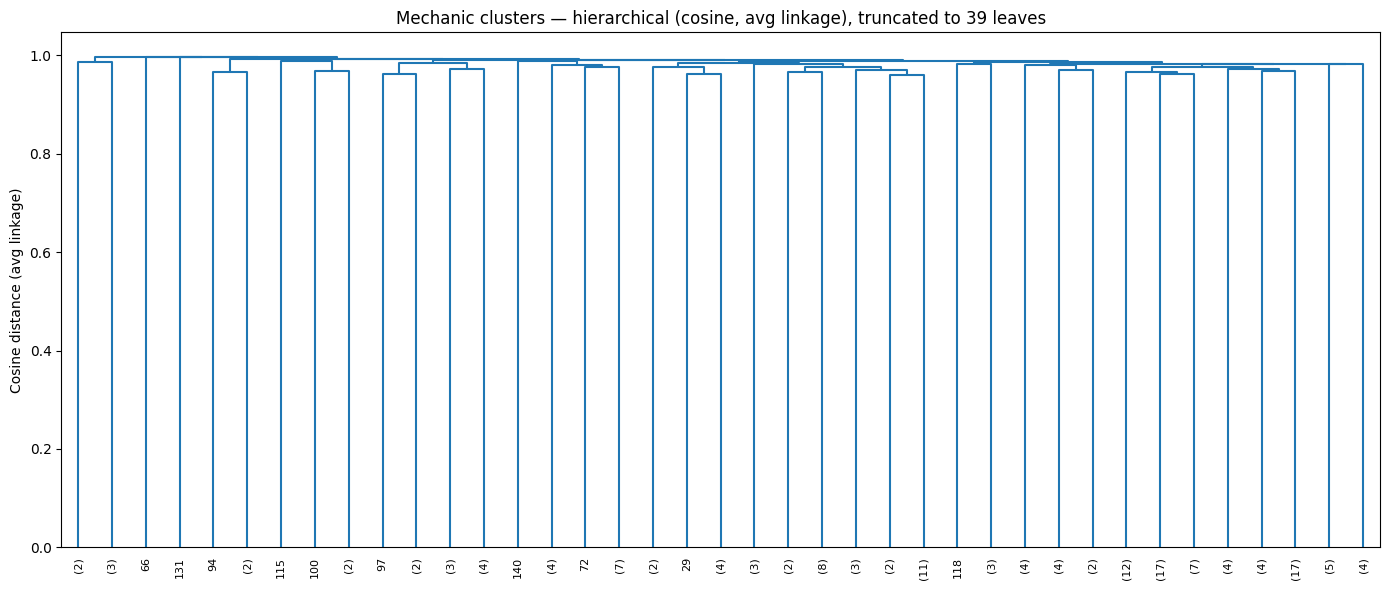


=== Mechanic (adaptive cut, k=39) clusters (cluster, 39 clusters) ===

Cluster   1  (size   8, total n_games 5395)
  top: Tile Placement, Pattern Building, Real-Time, Dexterity, Pattern Recognition, Enclosure, Speed Matching, Action Timer

Cluster   2  (size   8, total n_games 1509)
  top: Worker Placement, End Game Bonuses, TableauBuilding, Contracts, Income, Increase Value of Unchosen Resources, Automatic Resource Growth, Advantage Token

Cluster   3  (size   8, total n_games 1405)
  top: Network and Route Building, Stock Holding, Commodity Speculation, Market, Victory Points as a Resource, Ownership, Investment, Loans

Cluster   4  (size   8, total n_games 14293)
  top: Dice Rolling, Simulation, Hexagon Grid, Grid Movement, Movement Points, Ratio / Combat Results Table, Scenario / Mission / Campaign Game, Zone of Control

Cluster   5  (size   8, total n_games 5474)
  top: Deduction, Betting and Bluffing, Team-Based Game, Memory, Voting, Hidden Roles, Traitor Game, Roles with Asymme

In [11]:
# --- Figure 5: mechanics ---
mech_df, mech_Z, mech_feats, mech_X, mech_k = hcluster_features(
    MECH_SAN, max_size=8, k_min=30, k_max=60, k_coarse=12, kind="mechanic")
mech_df.to_csv(FIG_DIR / "fig05_mechanic_assignments.csv", index=False)
save_dendrogram(mech_Z, mech_feats,
                FIG_DIR / "fig05_mechanic_dendrogram.png",
                f"Mechanic clusters — hierarchical (cosine, avg linkage), truncated to {mech_k} leaves",
                p=mech_k)
print_clusters(mech_df, "cluster", f"Mechanic (adaptive cut, k={mech_k})")
print_clusters(mech_df, "cluster_k12", "Mechanic (coarse, k=12)", max_examples=15)


In [12]:
# --- Per-cluster summary CSV for hand-labeling ---
# Saved to results/mechanic_clusters.csv (not results/figures/). One row per
# cluster, with a `label` column the user fills in manually.
#
# Idempotent — but strict: existing labels are preserved only when the
# cluster's `mechanics` column is byte-identical to a previous row. If
# even one mechanic moves in or out of a cluster (or the ordering changes
# because centrality shifted), the label is cleared. This means a
# parameter sweep that reshuffles cluster contents wipes labels rather
# than silently mis-attributing them.
CLUSTER_LABELS_PATH = Path("../results/mechanic_clusters.csv")

summary_rows = []
for cid in sorted(mech_df["cluster"].unique()):
    sub = mech_df[mech_df["cluster"] == cid]
    # Sort alphabetically so the `mechanics` string is a stable, comparable
    # representation of cluster MEMBERSHIP — independent of centrality order.
    mechs = sorted(sub["feature"].tolist(), key=str.lower)
    summary_rows.append({
        "cluster_id": int(cid),
        "size": int(len(sub)),
        "n_games_sum": int(sub["n_games"].sum()),
        "mechanics": "; ".join(mechs),
        "label": "",
    })
summary_df = pd.DataFrame(summary_rows).sort_values(
    "n_games_sum", ascending=False
).reset_index(drop=True)

if CLUSTER_LABELS_PATH.exists():
    existing = pd.read_csv(CLUSTER_LABELS_PATH)
    if {"mechanics", "label"}.issubset(existing.columns):
        prev = existing.set_index("mechanics")["label"].dropna().astype(str)
        prev = prev[prev.str.strip() != ""]
        summary_df["label"] = summary_df["mechanics"].map(prev).fillna("")
        n_preserved = (summary_df["label"] != "").sum()
        n_dropped = len(prev) - n_preserved
        print(f"Preserved {n_preserved} labels by exact mechanics match"
              + (f"  ({n_dropped} cleared — cluster contents changed)" if n_dropped else ""))

summary_df.to_csv(CLUSTER_LABELS_PATH, index=False)
print(f"Saved {CLUSTER_LABELS_PATH.resolve()}  ({len(summary_df)} clusters)")
summary_df


Preserved 0 labels by exact mechanics match
Saved /Users/lucaban/ghq/github.com/craftingtablestudio/ludometrics/results/mechanic_clusters.csv  (39 clusters)


,cluster_id,size,n_games_sum,mechanics,label
0,4,8,14293,Dice Rolling; Grid Movement; Hexagon Grid; Movement Points; Ratio / Combat Results Table; Scenario / Mission / Campaign Game; Simulation; Zone of Control,
1,12,5,11392,"Deck, Bag, and Pool Building; Drafting; Hand Management; Set Collection; Take That",
2,13,5,8473,Action Points; Area Majority / Influence; Area Movement; Modular Board; Variable Player Powers,
3,5,8,5474,Betting and Bluffing; Deduction; Hidden Roles; Memory; Roles with Asymmetric Information; Team-Based Game; Traitor Game; Voting,
4,1,8,5395,Action Timer; Dexterity; Enclosure; Pattern Building; Pattern Recognition; Real-Time; Speed Matching; Tile Placement,
5,11,5,4574,Auction/Bidding; Negotiation; Player Elimination; Roll / Spin and Move; Trading,
6,7,7,3714,Cooperative Game; Elapsed Real Time Ending; Move Through Deck; Narrative Choice / Paragraph; Role Playing; Solo / Solitaire Game; Storytelling,
7,17,4,1695,Action Queue; Bias; Programmed Movement; Simultaneous Action Selection,
8,2,8,1509,Advantage Token; Automatic Resource Growth; Contracts; End Game Bonuses; Income; Increase Value of Unchosen Resources; TableauBuilding; Worker Placement,
9,30,2,1502,Campaign / Battle Card Driven; Point to Point Movement,


## Saved file summary


In [13]:
import os
print("Files in results/figures/:")
files = sorted(FIG_DIR.iterdir())
for f in files:
    size = f.stat().st_size
    if size >= 1024:
        sz = f"{size/1024:.1f} KB"
    else:
        sz = f"{size} B"
    print(f"  {f.name:60s} {sz}")
print(f"\nTotal: {len(files)} files")


Files in results/figures/:
  fig01_dual_prediction_data.csv                               1.6 KB
  fig01_dual_prediction_summary.png                            79.2 KB
  fig02_shap_waterfall_backgammon_commercial.png               60.9 KB
  fig02_shap_waterfall_backgammon_quality.png                  62.0 KB
  fig02_shap_waterfall_battleship_commercial.png               61.7 KB
  fig02_shap_waterfall_battleship_quality.png                  65.6 KB
  fig02_shap_waterfall_carcassonne_commercial.png              62.0 KB
  fig02_shap_waterfall_carcassonne_quality.png                 59.6 KB
  fig02_shap_waterfall_cards_against_humanity_commercial.png   62.1 KB
  fig02_shap_waterfall_cards_against_humanity_quality.png      62.3 KB
  fig02_shap_waterfall_catan_commercial.png                    56.9 KB
  fig02_shap_waterfall_catan_quality.png                       55.4 KB
  fig02_shap_waterfall_chess_commercial.png                    60.2 KB
  fig02_shap_waterfall_chess_quality.png           